# <center>Đồ án 1: Hồi quy tuyến tính</center>

# Thông tin sinh viên

- Họ và tên: Trần Trọng Tú 
- MSSV: 24122024
- Lớp: 24TNT1

# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Đọc dữ liệu

In [2]:
# Doc du lieu
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Kich thuoc train:', train.shape)
print('Kich thuoc test :', test.shape)

# Thiet lap cho bo Ames
# - train.csv co cot muc tieu SalePrice
# - test.csv cung co cot SalePrice de danh gia mo hinh
TARGET_COL = 'SalePrice'
ID_COL = 'Id'
# errors='ignore': Một kỹ thuật an toàn. Nếu bạn chạy lại cell này nhiều lần, 
# tập dữ liệu có thể không còn cột Id nữa. Tham số này giúp code không bị văng lỗi (crash).

X_train_full = train.drop(columns=[TARGET_COL, ID_COL], errors='ignore').copy()
y_train_full = train[TARGET_COL].copy() # return Pandas Series 1D, not a DF 2D
X_test = test.drop(columns=[TARGET_COL, ID_COL], errors='ignore').copy()
y_test = test[TARGET_COL].copy()

# Dong bo thu tu cot giua tap train va test(để có thể nhân ma trận theo đứng đặc trưng)
X_test = X_test.reindex(columns=X_train_full.columns)

print('So dac trung dau vao:', X_train_full.shape[1])
print('Cot muc tieu:', TARGET_COL)

Kich thuoc train: (1460, 81)
Kich thuoc test : (1459, 81)
So dac trung dau vao: 79
Cot muc tieu: SalePrice


# Cài đặt hàm

In [3]:
def preprocess_data(X_train_raw, X_test_raw): # explain why do this would be latter 
    X_train = X_train_raw.copy() 
    X_test = X_test_raw.copy()

    # Group 1 & 2: Categorical features where NaN means "Does not exist"
    cat_none_cols = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', # Group 1
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', # Group 2 (Garage)
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2' # Group 2 (Basement)
    ]
    
    # Group 2: Numerical features where NaN means 0 (No garage / No basement)
    num_zero_cols = [
        'GarageYrBlt', 'GarageArea', 'GarageCars', 
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath'
    ]

    # --- 1. HANDLE GROUP 1 & 2z: NaN means None ---
    # Fill categorical with 'None'
    for col in cat_none_cols:
        X_train[col] = X_train[col].fillna('None')
        X_test[col] = X_test[col].fillna('None')

    # Fill numerical with 0
    for col in num_zero_cols:
        X_train[col] = X_train[col].fillna(0)
        X_test[col] = X_test[col].fillna(0)

    # --- 2. HANDLE GROUP 3 (Truly Missing Data) ---
    # LotFrontage: Fill with Median
    if 'LotFrontage' in X_train.columns:
        median_lf = X_train['LotFrontage'].median() # TRAIN SET ONLY 
        X_train['LotFrontage'] = X_train['LotFrontage'].fillna(median_lf) 
        X_test['LotFrontage'] = X_test['LotFrontage'].fillna(median_lf) # APPLIED TRAIN SET 

    # Electrical: Fill with mode, why do this: see explain in markdown later
    if 'Electrical' in X_train.columns:
        mode_elec = X_train['Electrical'].mode()[0]
        X_train['Electrical'] = X_train['Electrical'].fillna(mode_elec)
        X_test['Electrical'] = X_test['Electrical'].fillna(mode_elec)

    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_train.select_dtypes(include=['object', 'string']).columns

    # Remaining numerical -> median
    for col in num_cols:
        if X_train[col].isnull().sum() > 0 or X_test[col].isnull().sum() > 0:
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)

    # Remaining categorical -> Mode
    for col in cat_cols:
        if X_train[col].isnull().sum() > 0 or X_test[col].isnull().sum() > 0:
            mode_val = X_train[col].mode()[0]
            X_train[col] = X_train[col].fillna(mode_val)
            X_test[col] = X_test[col].fillna(mode_val)

     # One-Hot Encoding
    X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=float) 
    train_columns = X_train_encoded.columns

    X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=float)

    # Align test set columns with train set (Drop unseen, add missing with 0)
    X_test_encoded = X_test_encoded.reindex(columns=train_columns, fill_value=0.0)

    # Return numpy arrays to calculate ez, and feature_names for references and generate again data
    return X_train_encoded.to_numpy(), X_test_encoded.to_numpy(), train_columns

Việc sử dụng `drop_first=True` là bắt buộc vì 3 lý do toán học sau:

**1. Đảm bảo tính duy nhất và khả năng giải thích của trọng số:**
Nếu giữ nguyên sự phụ thuộc tuyến tính, hệ phương trình dự đoán sẽ có vô số nghiệm $\mathbf{w}$ cho ra cùng một giá trị $\hat{y}$. Trọng số học được sẽ trở nên vô nghĩa. Khi dùng `drop_first=True`, cột cơ sở bị loại bỏ sẽ được gộp chung vào Intercept. Các trọng số còn lại lúc này mang ý nghĩa rõ ràng: *"Đặc trưng này làm tăng/giảm giá nhà bao nhiêu so với nhóm cơ sở?"*

**2. Tăng tốc độ hội tụ:**
Sự đa cộng tuyến làm bề mặt hàm mất mát bị méo mó, tạo ra các "khe núi phẳng" dọc theo các chiều bị phụ thuộc. Gradient Descent sẽ bị mất phương hướng, dao động liên tục và tiến lên rất chậm chạp, tốn rất nhiều vòng lặp (epochs) mà vẫn khó tiệm cận được điểm tối ưu toàn cục.

**3. Tối ưu hóa tài nguyên tính toán:**
Tập dữ liệu Ames Housing chứa rất nhiều biến phân loại. Việc loại bỏ triệt để các cột dư thừa cho mỗi biến giúp giảm kích thước chiều dữ liệu. Điều này làm giảm chi phí tính toán cho các phép nhân ma trận $\mathbf{X}\mathbf{w}$ và $\mathbf{X}^T\mathbf{e}$ trong mỗi vòng lặp của Gradient Descent, giúp thuật toán chạy nhanh và tiết kiệm bộ nhớ hơn.

In [4]:
# Data normalization function using Z-score standardization
def standardize_data(X_train, X_test):
    """
    Perform Z-score standardization on the dataset to achieve zero mean and unit variance.

    Parameters:
    X_train, X_test : np.ndarray: preprocessed data 
        
    Returns:
    X_train_scaled, X_test_scaled: np.ndarray
        
    """
    # Calculate mean and standard deviation from the training only
    mean = np.mean(X_train, axis = 0)
    std = np.std(X_train, axis = 0)
    
    # Add a tiny epsilon to avoid division by zero
    epsilon = 1e-8
    
    # Standardize both training and testing sets
    X_train_scaled = (X_train - mean) / (std + epsilon)
    X_test_scaled = (X_test - mean) / (std + epsilon)
    
    return X_train_scaled, X_test_scaled

def add_intercept(X):
    """
    Add bias (intercept) column of ones to feature matrix.
    
    Parameters:
    X: Feature matrix of shape (n_samples, n_features)
    
    Returns:
    X_padded: Matrix of shape (n_samples, n_features + 1) with intercept column
    """
    return np.c_[np.ones((X.shape[0], 1)), X]

class CustomLinearRegression: 
    def __init__(self, learning_rate=0.01, decay_rate=0.001, epochs=10000, tol=1e-3, delta=0.5, l2_lambda=0.0):
        """
        Linear Regression using Gradient Descent optimizing for Huber loss.

        Parameters:
        learning_rate: Initial step size for gradient descent
        decay_rate: Inverse time decay rate for learning rate scheduling
        epochs: Number of iterations for gradient descent
        tol: Relative tolerance for early stopping
        delta: Huber threshold between L2 and L1 region
        l2_lambda: Ridge regularization strength to avoid overfitting 
        """
        self.learning_rate = learning_rate
        self.decay_rate = decay_rate
        self.epochs = epochs
        self.tol = tol
        self.delta = delta
        self.l2_lambda = l2_lambda
        
        self.weights = None
        self.loss_history = []

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Fit the model using Gradient Descent.
        
        Parameters:
        X: Scaled feature matrix
        y: Target array 
        """
        X_padded = add_intercept(X)
        n_samples = X_padded.shape[0]

        # Initialize weights
        self.weights = np.zeros(X_padded.shape[1])
        # Smart initialization for intercept since X is scaled
        self.weights[0] = np.mean(y)

        self.loss_history = []
        initial_learning_rate = self.learning_rate

        for epoch in range(self.epochs):
            y_pred = X_padded @ self.weights
            errors = y_pred - y
            abs_errors = np.abs(errors)

            # Calculate Huber derivative
            huber_grad = np.where(abs_errors <= self.delta, errors, self.delta * np.sign(errors))
            
            # Mean gradient of the loss
            gradient = (X_padded.T @ huber_grad) / n_samples

            # L2 regularization gradient (excluding the intercept at index 0)
            reg_grad = np.r_[0.0, self.l2_lambda * self.weights[1:]]
            gradient += reg_grad

            # Apply inverse time decay to learning rate
            current_lr = initial_learning_rate / (1 + self.decay_rate * epoch)
            self.weights -= current_lr * gradient

            # Track Huber + L2 objective function
            huber_loss = np.where(
                abs_errors <= self.delta,
                0.5 * (errors ** 2),
                self.delta * (abs_errors - 0.5 * self.delta)
            )
            
            reg_loss = 0.5 * self.l2_lambda * np.sum(self.weights[1:] ** 2)
            self.loss_history.append(np.mean(huber_loss) + reg_loss)
            
            # Early stopping check logic
            if epoch > 100 and epoch % 100 == 0:
                recent_loss = np.mean(self.loss_history[-10:])
                old_loss = np.mean(self.loss_history[-20:-10])
                relative_improvement = abs(old_loss - recent_loss) / (old_loss + 1e-8)

                if relative_improvement < self.tol and epoch > 300:
                    break

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict target values for input X.
        """
        X_padded = add_intercept(X)
        return X_padded @ self.weights


*Chú thích: Cần có docstrings cho các hàm.*

In [5]:
def mean_absolute_error(y_true, y_pred):
    """
    Calculate the Mean Absolute Error (MAE) between true and predicted values.
    """
    absolute_errors = np.abs(y_true - y_pred)
    return np.mean(absolute_errors)


In [6]:
def create_k_folds(n_samples, k=5, seed=42):
    """
    Creates K folds for cross-validation by shuffling indices only once.
    
    Args:
        n_samples: int
        k (int): Number of folds (default is 5).
        seed (int): Random seed for reproducibility (default is 42).
        
    Returns:
        list: A list containing 'k' numpy arrays of indices.
    """
    if seed is not None:
        np.random.seed(seed)
        
    # 1. Generate an array of indices [0, 1, ..., n_samples-1] and shuffle it
    shuffled_indices = np.random.permutation(n_samples)
    
    # 2. Split the shuffled indices into K equal (or nearly equal) chunks
    folds = np.array_split(shuffled_indices, k)
    
    return folds

In [7]:
def evaluate_model_cv(X_input, y_input, folds, dic):
    K = len(folds)
    fold_maes = []
    TARGET_SCALE = 100000.0 # Target Scaling
    
    for i in range(K):
        # Get validation and training indices
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(K) if j != i])
        
        # Split data
        X_cv_train = X_input[train_idx]
        y_cv_train = y_input[train_idx]
        X_cv_val = X_input[val_idx]
        y_cv_val = y_input[val_idx] 
        
        X_cv_train_scaled, X_cv_val_scaled = standardize_data(X_cv_train, X_cv_val)
        
        # scale target
        y_cv_train_scaled = y_cv_train / TARGET_SCALE
        
        # Train 
        model = CustomLinearRegression(**dic)
        model.fit(X_cv_train_scaled, y_cv_train_scaled)
        
        # Predict 
        y_pred_scaled = model.predict(X_cv_val_scaled)
        # back to original scale
        y_pred_original_scale = y_pred_scaled * TARGET_SCALE
        
        # Calculate MAE 
        mae = mean_absolute_error(y_cv_val, y_pred_original_scale) 
        fold_maes.append(mae)
        
    return np.mean(fold_maes)

In [8]:
def print_regression_formula(trained_model, feature_names, TARGET_SCALE):
    """
    Generate a LaTeX regression formula, inverse-transforming the weights
    so the formula outputs values in the original scale (Actual USD).
    """
    
    # Extract weights and multiply by TARGET_SCALE to recover original magnitude
    bias = np.round(trained_model.weights[0] * TARGET_SCALE, 3)
    coefficients = np.round(trained_model.weights[1:] * TARGET_SCALE, 3)
    
    # Start building the LaTeX formula
    formula = f"$$\\hat{{y}} = {bias}"
    
    for coef, name in zip(coefficients, feature_names):
        clean_name = name.replace("_", "\\_")
        if coef >= 0:
            formula += f" + {coef} \\cdot \\text{{{clean_name}}}"
        else:
            formula += f" - {abs(coef)} \\cdot \\text{{{clean_name}}}"
            
    formula += "$$"
    
    print("Regression Formula (Copy this to a Markdown cell):")
    print(formula)

In [9]:
def create_features_option_1_2c(df):
    df_copy = df.copy()
    
    def _num_col(name, default=0.0):
        if name in df_copy.columns:
            return pd.to_numeric(df_copy[name], errors='coerce').fillna(default)
        return pd.Series(default, index=df_copy.index, dtype=float)
    
    gr_liv = _num_col('GrLivArea')
    bsmt = _num_col('TotalBsmtSF')
    garage_area = _num_col('GarageArea')
    garage_cars = _num_col('GarageCars')
    full_bath = _num_col('FullBath')
    half_bath = _num_col('HalfBath')
    bsmt_full_bath = _num_col('BsmtFullBath')
    bsmt_half_bath = _num_col('BsmtHalfBath')
    bed_abv = _num_col('BedroomAbvGr')
    overall_qual = _num_col('OverallQual')
    overall_cond = _num_col('OverallCond', default=5.0)
    yr_sold = _num_col('YrSold')
    year_built = _num_col('YearBuilt')
    year_remod = _num_col('YearRemodAdd')
    bsmt_fin_1 = _num_col('BsmtFinSF1')
    bsmt_fin_2 = _num_col('BsmtFinSF2')
    open_porch = _num_col('OpenPorchSF')
    enclosed_porch = _num_col('EnclosedPorch')
    s3_porch = _num_col('3SsnPorch')
    screen_porch = _num_col('ScreenPorch')
    wood_deck = _num_col('WoodDeckSF')
    
    effective_year_built = np.maximum(year_built, year_remod.where(year_remod > 0, year_built))
    house_age = (yr_sold - effective_year_built).clip(lower=0)
    remod_age = (yr_sold - year_remod.where(year_remod > 0, year_built)).clip(lower=0)
    total_bath = full_bath + 0.5 * half_bath + bsmt_full_bath + 0.5 * bsmt_half_bath + 0.25 * bed_abv
    total_sqft = gr_liv + bsmt + 0.35 * garage_area
    quality_score = overall_qual + 0.25 * overall_cond
    
    df_copy['Total_SqFt'] = total_sqft
    df_copy['Total_Bath'] = total_bath
    df_copy['OverallQual'] = quality_score
    df_copy['House_Age'] = house_age
    df_copy['Total_PorchSF'] = open_porch + enclosed_porch + s3_porch + screen_porch + wood_deck
    df_copy['Bath_per_Bedroom'] = total_bath / (bed_abv + 1.0)
    df_copy['Living_to_Bsmt_Ratio'] = gr_liv / (bsmt + 1.0)
    df_copy['House_Age_Sq'] = np.square(house_age)
    df_copy['Qual_x_SqFt'] = quality_score * np.log1p(total_sqft)
    df_copy['Garage_Impact'] = garage_cars * np.log1p(garage_area + 1.0)
    df_copy['Bsmt_Finish_Ratio'] = (bsmt_fin_1 + bsmt_fin_2) / (bsmt + 1.0)
    df_copy['Remod_Age'] = remod_age
    df_copy['Recent_Remodel_Flag'] = (remod_age <= 10).astype(float)
    
    return df_copy

In [10]:
def create_features_option_2_2c(df):
    df_copy = df.copy()
    
    def _num_col(name, default=0.0):
        if name in df_copy.columns:
            return pd.to_numeric(df_copy[name], errors='coerce').fillna(default)
        return pd.Series(default, index=df_copy.index, dtype=float)
    
    overall_qual = _num_col('OverallQual')
    overall_cond = _num_col('OverallCond', default=5.0)
    gr_liv = _num_col('GrLivArea')
    bsmt = _num_col('TotalBsmtSF')
    first_flr = _num_col('1stFlrSF')
    second_flr = _num_col('2ndFlrSF')
    garage_cars = _num_col('GarageCars')
    full_bath = _num_col('FullBath')
    half_bath = _num_col('HalfBath')
    bsmt_full_bath = _num_col('BsmtFullBath')
    bsmt_half_bath = _num_col('BsmtHalfBath')
    rooms = _num_col('TotRmsAbvGrd', default=1.0)
    yr_sold = _num_col('YrSold')
    year_built = _num_col('YearBuilt')
    year_remod = _num_col('YearRemodAdd')
    
    weighted_qual = overall_qual + 0.3 * overall_cond
    adjusted_liv = gr_liv + 0.2 * second_flr
    adjusted_bsmt = bsmt + 0.15 * first_flr
    total_area = adjusted_liv + adjusted_bsmt
    house_age = (yr_sold - np.maximum(year_built, year_remod.where(year_remod > 0, year_built))).clip(lower=0)
    remod_age = (yr_sold - year_remod.where(year_remod > 0, year_built)).clip(lower=0)
    total_bath = full_bath + 0.5 * half_bath + bsmt_full_bath + 0.5 * bsmt_half_bath
    log_liv = np.log1p(adjusted_liv.clip(lower=0))
    log_bsmt = np.log1p(adjusted_bsmt.clip(lower=0))
    log_total_area = np.log1p(total_area.clip(lower=0))
    
    df_copy['OverallQual_Sq'] = np.square(weighted_qual)
    df_copy['Log_GrLivArea'] = log_liv
    df_copy['Log_TotalBsmtSF'] = log_bsmt
    df_copy['House_Age'] = house_age
    
    # Nhiều đặc trưng phi tuyến và tương tác hơn
    df_copy['OverallQual_Cu'] = np.power(weighted_qual, 3)
    df_copy['Qual_x_LogLiv'] = weighted_qual * log_liv
    df_copy['Qual_x_LogBsmt'] = weighted_qual * log_bsmt
    df_copy['Age_x_Qual'] = house_age * weighted_qual
    df_copy['Remod_Age'] = remod_age
    df_copy['Remod_Recency'] = 1.0 / (remod_age + 1.0)
    df_copy['Log_TotalArea'] = log_total_area
    df_copy['Liv_Bsmt_Gap'] = adjusted_liv - adjusted_bsmt
    df_copy['Bath_x_Qual'] = total_bath * weighted_qual
    df_copy['Garage_x_Qual'] = garage_cars * weighted_qual
    df_copy['Room_Density'] = rooms / (log_total_area + 1.0)
    
    return df_copy

In [11]:
def create_features_option_3_2c(df):
    df_copy = df.copy() 

    # Group 1 & 2: Categorical features where NaN means "Does not exist"
    cat_none_cols = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', # Group 1
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', # Group 2 (Garage)
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2' # Group 2 (Basement)
    ]
    
    # Group 2: Numerical features where NaN means 0 (No garage / No basement)
    num_zero_cols = [
        'GarageYrBlt', 'GarageArea', 'GarageCars', 
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath'
    ]

    # --- 1. HANDLE GROUP 1 & 2z: NaN means None ---
    # Fill categorical with 'None'
    for col in cat_none_cols:
        df_copy[col] = df_copy[col].fillna('None')

    # Fill numerical with 0
    for col in num_zero_cols:
        df_copy[col] = df_copy[col].fillna(0)

    # --- 2. HANDLE GROUP 3 (Truly Missing Data) ---
    # LotFrontage: Fill with Median
    if 'LotFrontage' in df_copy.columns:
        median_lf = df_copy['LotFrontage'].median() # TRAIN SET ONLY 
        df_copy['LotFrontage'] = df_copy['LotFrontage'].fillna(median_lf) 

    # Electrical: Fill with mode, why do this: see explain in markdown later
    if 'Electrical' in df_copy.columns:
        mode_elec = df_copy['Electrical'].mode()[0]
        df_copy['Electrical'] = df_copy['Electrical'].fillna(mode_elec)

    num_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df_copy.select_dtypes(include=['object', 'string']).columns

    # Remaining numerical -> median
    for col in num_cols:
        if df_copy[col].isnull().sum() > 0 or X_test[col].isnull().sum() > 0:
            median_val = df_copy[col].median()
            df_copy[col] = df_copy[col].fillna(median_val)

    # Remaining categorical -> Mode
    for col in cat_cols:
        if df_copy[col].isnull().sum() > 0 or X_test[col].isnull().sum() > 0:
            mode_val = df_copy[col].mode()[0]
            df_copy[col] = df_copy[col].fillna(mode_val)
    
    def _num_col(name, default=0.0):
        if name in df_copy.columns:
            return pd.to_numeric(df_copy[name], errors='coerce').fillna(default)
        return pd.Series(default, index=df_copy.index, dtype=float)
    
    def _cat_col(name, default='TA'):
        if name in df_copy.columns:
            return df_copy[name].fillna(default).astype(str)
        return pd.Series(default, index=df_copy.index, dtype='object')
    
    gr_liv = _num_col('GrLivArea')
    bsmt = _num_col('TotalBsmtSF')
    rooms = _num_col('TotRmsAbvGrd', default=1.0)
    overall_qual = _num_col('OverallQual')
    overall_cond = _num_col('OverallCond', default=5.0)
    yr_sold = _num_col('YrSold')
    year_built = _num_col('YearBuilt')
    year_remod = _num_col('YearRemodAdd')
    full_bath = _num_col('FullBath')
    half_bath = _num_col('HalfBath')
    bsmt_full_bath = _num_col('BsmtFullBath')
    bsmt_half_bath = _num_col('BsmtHalfBath')
    garage_area = _num_col('GarageArea')
    garage_cars = _num_col('GarageCars')
    
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
    exter_score = _cat_col('ExterQual').map(qual_map).fillna(3).astype(float)
    kitchen_score = _cat_col('KitchenQual').map(qual_map).fillna(3).astype(float)
    bsmt_score = _cat_col('BsmtQual').map(qual_map).fillna(3).astype(float)
    garage_score = _cat_col('GarageQual').map(qual_map).fillna(3).astype(float)
    
    effective_year_built = np.maximum(year_built, year_remod.where(year_remod > 0, year_built))
    house_age = (yr_sold - effective_year_built).clip(lower=0)
    remod_age = (yr_sold - year_remod.where(year_remod > 0, year_built)).clip(lower=0)
    total_bath = full_bath + 0.5 * half_bath + bsmt_full_bath + 0.5 * bsmt_half_bath
    effective_living = gr_liv + 0.35 * bsmt
    blended_quality = exter_score * kitchen_score + 0.4 * overall_qual * overall_cond + 0.25 * bsmt_score * garage_score
    log_bsmt = np.log1p((bsmt + 0.1 * gr_liv).clip(lower=0))
    log_total_area = np.log1p((gr_liv + bsmt + 0.3 * garage_area).clip(lower=0))
    
    df_copy['AvgRoomSize'] = effective_living / (rooms + 0.5)
    df_copy['QualityInteraction'] = blended_quality
    df_copy['House_Age'] = house_age
    df_copy['Log_TotalBsmtSF'] = log_bsmt
    
    # Thêm đặc trưng mở rộng cho mô hình log-target
    df_copy['Qual_per_Age'] = blended_quality / (house_age + 1.0)
    df_copy['Log_TotalArea'] = log_total_area
    df_copy['Remod_Age'] = remod_age
    df_copy['Remod_Recency'] = 1.0 / (remod_age + 1.0)
    df_copy['Bath_to_Room'] = total_bath / (rooms + 1.0)
    df_copy['Garage_Quality_Impact'] = garage_cars * garage_score
    df_copy['BsmtQual_x_LogBsmt'] = bsmt_score * log_bsmt
    df_copy['Quality_x_Area'] = blended_quality * log_total_area
    
    return df_copy

In [12]:
def evaluate_model_cv_option_3_2c_with_log(X_input, y_input, folds, dic):
    K = len(folds)
    fold_maes = []
    
    for i in range(K):
        # Get validation and training indices
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(K) if j != i])
        
        # Split data
        X_cv_train = X_input[train_idx]
        y_cv_train = y_input[train_idx]
        X_cv_val = X_input[val_idx]
        y_cv_val = y_input[val_idx]
        
        X_cv_train_scaled, X_cv_val_scaled = standardize_data(X_cv_train, X_cv_val)
        
        # Train model (Use the SCALED training data)
        model = CustomLinearRegression(**dic)
        model.fit(X_cv_train_scaled, y_cv_train) # y is transformed into log 
        
        # Predict using the SCALED validation data
        y_pred_log = model.predict(X_cv_val_scaled)
        
        # Cap max value to 20 (exp(20) is ~$485M, which is extremely safe for housing prices)
        y_pred_log_safe = np.clip(y_pred_log, a_min=None, a_max=20)
        
        # Inverse transform to real USD 
        y_pred_real = np.expm1(y_pred_log_safe)
        y_cv_real = np.expm1(y_cv_val)
        
        mae = mean_absolute_error(y_cv_real, y_pred_real)
        fold_maes.append(mae)
        
    # Return the average MAE across all folds
    return np.mean(fold_maes)

# Yêu cầu 1: Phân tích khám phá dữ liệu (1 điểm)

Thực hiện Exploratory Data Analysis chủ yếu trên tập huấn luyện.
Có thể đối chiếu thống kê cơ bản giữa tập huấn luyện và tập kiểm tra, nhưng không dùng tập kiểm tra để điều chỉnh mô hình.

In [13]:
# Phân tích khám phá dữ liệu thông qua thống kê và các biểu đồ
# Chỉ được phân tích trên tập huấn luyện

# 1. Print basic information about the training dataset
print("--- BASIC INFORMATION ---")
print("Number of rows:", X_train_full.shape[0])
print("Number of columns:", X_train_full.shape[1])
print("First 5 rows of the training dataset: ")
display(X_train_full.head(5)) 
print("\nData types overview:")
print(X_train_full.dtypes.value_counts())
print("-------------------------")
print('\nGeneral info: ')
X_train_full.info() 


--- BASIC INFORMATION ---
Number of rows: 1460
Number of columns: 79
First 5 rows of the training dataset: 


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal



Data types overview:
str        43
int64      33
float64     3
Name: count, dtype: int64
-------------------------

General info: 
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460

In [14]:
# 2. Check for missing values in each column
missing_vals = X_train_full.isnull().sum() # check total None value for each col 
missing_vals = missing_vals[missing_vals > 0].sort_values(ascending=False) # filter out a col if it does not have a none value 
print("Columns with missing values:")
print(missing_vals)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [15]:
# For more info: check the percentage of missing values in each col to make better prediction 
missing_percentage = (missing_vals / len(X_train_full)) * 100
missing_info = pd.DataFrame({
    'Missing Values': missing_vals, 
    'Percentage (%)': missing_percentage.round(3)
})

print(f"Total columns with missing values: {len(missing_vals)}")
display(missing_info)

Total columns with missing values: 19


,Missing Values,Percentage (%)
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


### Nhận xét về tình trạng Dữ liệu thiếu (Missing Values)

Dựa vào bảng thống kê tỷ lệ dữ liệu thiếu, kết hợp với việc đối chiếu ý nghĩa các cột từ file `data_description.txt`, ta có thể chia các giá trị thiếu (NaN) thành 3 nhóm chính và định hướng cách xử lý như sau:

**1. Nhóm thiếu dữ liệu do "Không tồn tại":**
- Đứng đầu bảng là các cột `PoolQC` (99.5%), `MiscFeature` (96.3%), `Alley` (93.7%), `Fence` (80.7%), và `FireplaceQu` (47.2%).
- Theo mô tả dữ liệu, `NaN` ở các cột này không có nghĩa là dữ liệu bị lỗi hay bỏ sót, mà nó mang ý nghĩa thực tế là căn nhà đó **không có** hồ bơi, không có lối đi hẻm, không có hàng rào hay lò sưởi. 
- **Định hướng xử lý:** Thay vì xóa cột hay điền bằng giá trị xuất hiện nhiều nhất (mode), ta nên thay thế `NaN` bằng một chuỗi cụ thể như `"None"` để giữ lại thông tin "nhà không có tiện ích này".

**2. Nhóm thiếu dữ liệu theo "Cụm":**
- Nhóm các đặc trưng về **Garage** (`GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`, `GarageCond`) đều có tỷ lệ thiếu đồng loạt là **5.5%**. Điều này chỉ ra rằng có khoảng 5.5% số nhà trong tập dữ liệu không có Garage.
- Tương tự, nhóm đặc trưng về **Tầng hầm (Bsmt)** thiếu đồng loạt khoảng **2.5% - 2.6%**, nghĩa là những căn nhà đó không có tầng hầm.
- **Định hướng xử lý:** Với biến phân loại (chữ), ta điền `"None"`. Với biến dạng số (ví dụ: `GarageArea`, `BsmtFinSF1`), nếu không có gara hay hầm thì diện tích tương ứng sẽ được điền là `0` thay vì giá trị trung bình.

**3. Nhóm dữ liệu thực sự bị sót:**
- **`LotFrontage` (17.7%):** Mọi căn nhà đều phải có một độ dài mặt tiền nhất định nối với đường, nên đây là dữ liệu thực sự bị người thu thập bỏ sót. Ta điền bằng giá trị trung vị (Median).
- **`Electrical` (0.06%):** Chỉ thiếu duy nhất 1 dòng. Rất dễ dàng để xử lý bằng cách điền giá trị xuất hiện nhiều nhất (Mode).

In [16]:
# Descriptive statistics for numerical features
print("--- DESCRIPTIVE STATISTICS (NUMERICAL) ---")
num_cols = X_train_full.select_dtypes(include = ['int64', 'float64']).columns 
# decribe() function to caculate mean, std, các điểm phân vị 
display(X_train_full[num_cols].describe().round(1))

--- DESCRIPTIVE STATISTICS (NUMERICAL) ---


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.0,1201.0,1460.0,1460.0,1460.0,1460.0,1460.0,1452.0,1460.0,1460.0,...,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,56.9,70.0,10516.8,6.1,5.6,1971.3,1984.9,103.7,443.6,46.5,...,473.0,94.2,46.7,22.0,3.4,15.1,2.8,43.5,6.3,2007.8
std,42.3,24.3,9981.3,1.4,1.1,30.2,20.6,181.1,456.1,161.3,...,213.8,125.3,66.3,61.1,29.3,55.8,40.2,496.1,2.7,1.3
min,20.0,21.0,1300.0,1.0,1.0,1872.0,1950.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2006.0
25%,20.0,59.0,7553.5,5.0,5.0,1954.0,1967.0,0.0,0.0,0.0,...,334.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2007.0
50%,50.0,69.0,9478.5,6.0,5.0,1973.0,1994.0,0.0,383.5,0.0,...,480.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,6.0,2008.0
75%,70.0,80.0,11601.5,7.0,6.0,2000.0,2004.0,166.0,712.2,0.0,...,576.0,168.0,68.0,0.0,0.0,0.0,0.0,0.0,8.0,2009.0
max,190.0,313.0,215245.0,10.0,9.0,2010.0,2010.0,1600.0,5644.0,1474.0,...,1418.0,857.0,547.0,552.0,508.0,480.0,738.0,15500.0,12.0,2010.0


### Nhận xét từ bảng thống kê mô tả cho các đặc trưng số

Bảng thống kê trên cung cấp cái nhìn tổng quan về phân phối của 36 đặc trưng dạng số trong tập huấn luyện. Dưới đây là một số quan sát quan trọng:

- **Sự chênh lệch về thang đo (Scale):** Các đặc trưng có thang đo rất khác nhau. Ví dụ, `LotArea` (diện tích lô đất) có giá trị trung bình là $\approx 10516$ và giá trị lớn nhất lên tới $215245$, trong khi `OverallQual` (chất lượng tổng thể) chỉ dao động từ $1$ đến $10$. Sự chênh lệch này có thể ảnh hưởng đến thuật toán hồi quy tuyến tính, do đó cần tiền xử lý.
- **Dấu hiệu của giá trị ngoại lai (Outliers):** Một số cột có sự chênh lệch rất lớn giữa giá trị trung bình (mean) và giá trị lớn nhất (max), hoặc giữa bách phân vị thứ 75 (75%) và max:
  - `LotArea`: Bách phân vị thứ 75 là $11601.5$, nhưng giá trị lớn nhất lên tới $215245$.
  - `MiscVal` (giá trị các tiện ích khác): Hầu hết các nhà có giá trị là $0$ (từ bách phân vị 25% đến 75% đều bằng 0), nhưng có nhà đạt đến $15500$.
  - `BsmtFinSF1` (diện tích tầng hầm hoàn thiện): Max là $5644$ trong khi trung bình chỉ là $443.6$.
- **Vấn đề dữ liệu thiếu (Missing Data):** Số lượng (count) của một số cột nhỏ hơn tổng số dòng của dữ liệu ($1460$). Ví dụ: `LotFrontage` chỉ có $1201$ dòng có dữ liệu. Điều này xác nhận lại việc cần có chiến lược xử lý dữ liệu thiếu (điền giá trị trung bình/trung vị) trước khi đưa vào mô hình.
- **Đặc trưng phân loại nhưng mang kiểu số:** Một số cột như `MSSubClass` dù có kiểu dữ liệu số nhưng thực chất là biến phân loại (theo file mô tả, nó là mã định danh loại nhà).
- **Đặc trưng thời gian:** Các cột về năm như `YearBuilt` (1872 - 2010), `YearRemodAdd` (1950 - 2010) có phạm vi giá trị hợp lý, không có giá trị thời gian phi logic.


--- TARGET VARIABLE DISTRIBUTION ---


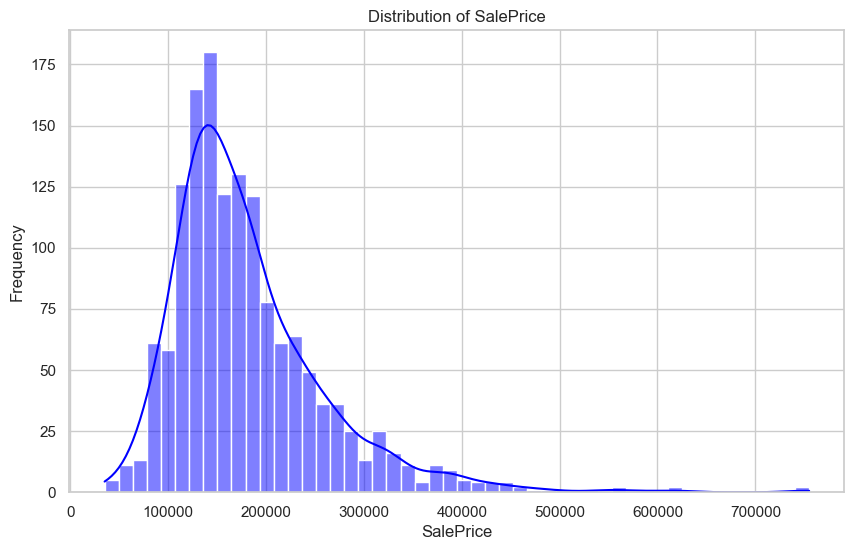

Skewness: 1.883
Kurtosis: 6.536


In [17]:
# Analyze the distribution of the target variable: SalePrice
print("\n--- TARGET VARIABLE DISTRIBUTION ---")

plt.figure(figsize=(10, 6))
# Plot histogram with a kernel density estimate (KDE) line
sns.histplot(y_train_full, kde=True, bins=50, color='blue')
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency') # số lượng nhà có SalePrice 
plt.show()

# Calculate and print Skewness (độ lệch) and Kurtosis (độ nhọn)
print(f"Skewness: {y_train_full.skew():.3f}")
print(f"Kurtosis: {y_train_full.kurt():.3f}")

### Nhận xét về phân phối của biến mục tiêu (SalePrice)

Dựa vào biểu đồ Histogram và các chỉ số thống kê, ta có thể rút ra những đặc điểm quan trọng của biến mục tiêu `SalePrice`:

* **Phân phối lệch phải (Right-Skewed):** Đồ thị có hình chuông nhưng không đối xứng. Phần đỉnh (chứa số lượng nhà nhiều nhất) tập trung ở mức giá từ 100,000 đến 200,000. Tuy nhiên, phần đuôi bên phải kéo rất dài, đại diện cho một số ít những căn nhà có giá trị rất cao (lên tới hơn 700,000).
* **Ý nghĩa của Skewness (Độ lệch):** Giá trị Skewness dương (> 0) xác nhận bằng toán học rằng dữ liệu đang bị lệch phải. Trong Hồi quy tuyến tính, nếu biến mục tiêu bị lệch, mô hình sẽ có xu hướng dự đoán kém hiệu quả hơn ở vùng giá trị cao và làm vi phạm giả định về phân phối chuẩn của sai số.
* **Ý nghĩa của Kurtosis (Độ nhọn):** Phân phối chuẩn hoàn hảo có Kurtosis = 3. Khi giá trị Kurtosis lớn hơn đáng kể, nó chỉ ra rằng phân phối này có phần "đuôi" nặng hơn (heavy tails), nghĩa là dữ liệu chứa nhiều giá trị ngoại lai (outliers) hơn bình thường. Những giá trị ngoại lai này có thể kéo lệch đường hồi quy, làm tăng sai số trung bình tuyệt đối (MAE).

Đây là định hướng cho câu 2c ở mô hình thứ ba: Để cải thiện hiệu suất của mô hình Hồi quy tuyến tính, một phương pháp phổ biến là áp dụng phép biến đổi Logarit ($y' = \log(y)$) lên `SalePrice` để kéo phân phối này về gần với phân phối chuẩn hơn, giúp mô hình học các trọng số $\mathbf{w}$ chính xác hơn.

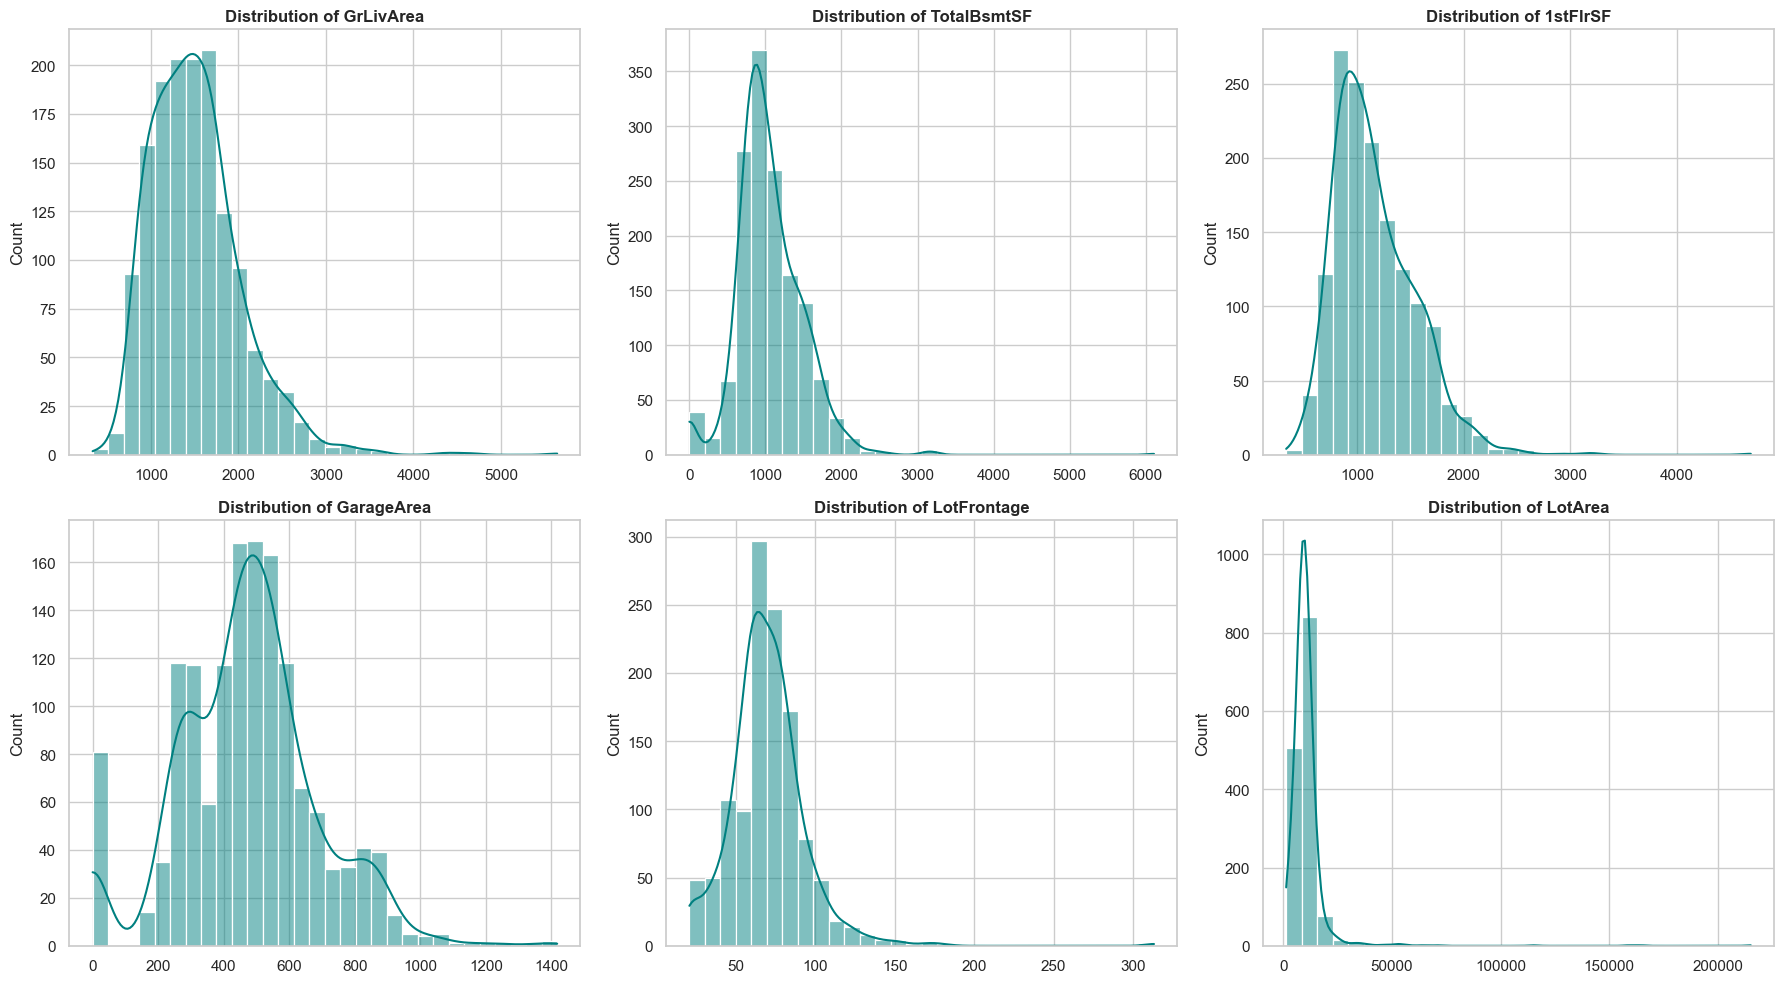

In [18]:
# Select some important continuous numeric columns
continuous_cols = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotFrontage', 'LotArea']

# Set up a grid of subplots 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Flatten to 1D array for easy looping

for i, col in enumerate(continuous_cols):
    # Plot histogram with a KDE curve to show the shape of the distribution
    sns.histplot(data=X_train_full, x=col, kde=True, ax=axes[i], color='teal', bins=30)
    
    # Customize titles and labels
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ phân phối của một số đặc trưng số 
- GrLivArea, 1stFlrSF, LotFrontage: Phân phối có hình chuông nhưng bị kéo dãn về bên phải. Nguyên nhân là do phần lớn các căn nhà có diện tích ở mức phổ thông, nhưng luôn tồn tại một lượng nhỏ các bất động sản có kích thước khổng lồ (Outliers / Điểm dị biệt), làm lệch trung bình (Mean) cao hơn trung vị (Median).

- LotArea (Diện tích lô đất): Mức độ lệch phải cực kỳ nghiêm trọng. Đỉnh của biểu đồ dồn ép sát trục tung, trong khi trục hoành kéo dài đến hơn 200.000. Điều này cho thấy có một vài "siêu dinh thự" hoặc điền trang có diện tích vượt trội hoàn toàn so với phần còn lại của tập dữ liệu.

- TotalBsmtSF & GarageArea (Diện tích Hầm & Gara): Phân phối có hình thái đặc biệt với một cột cao đột biến ngay tại giá trị 0 (Spike at zero). Điều này phản ánh hoàn toàn chính xác thực tế dữ liệu: có một tỷ lệ không nhỏ các căn nhà hoàn toàn không có tầng hầm hoặc không có Gara (tương ứng với giá trị 0). Phần dữ liệu còn lại (lớn hơn 0) vẫn duy trì hình thái lệch phải.


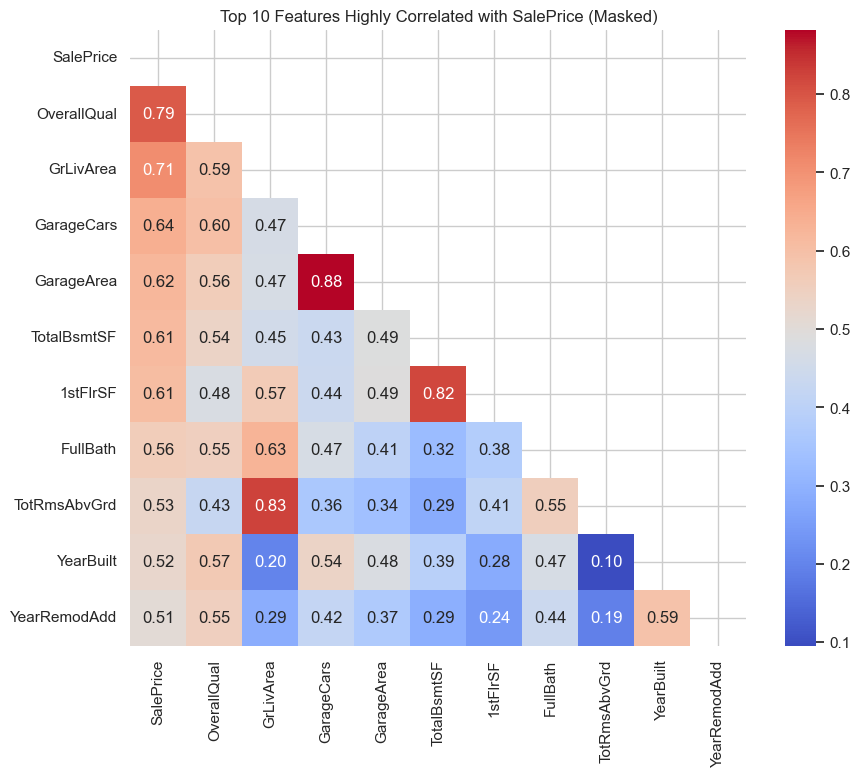

In [19]:
# 5. Correlation Heatmap (Top features correlated with SalePrice - Masked)

# Create a temporary dataframe combining numerical features and target
train_num_corr = X_train_full[num_cols].copy()
train_num_corr['SalePrice'] = y_train_full

# Calculate Pearson correlation matrix
corr_matrix = train_num_corr.corr()

# Get the top 10 features most correlated with SalePrice (plus SalePrice itself = 11)
k = 11 
top_corr_features = corr_matrix.nlargest(k, 'SalePrice')['SalePrice'].index

# Calculate the correlation matrix for these top features
top_corr_matrix = train_num_corr[top_corr_features].corr()

# Create a mask to hide the upper triangle and the diagonal (1.0 values)
# np.ones_like creates a matrix of True/False, np.triu isolates the upper triangle
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))

# Create and display the heatmap with the mask applied
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, mask=mask)
plt.title('Top 10 Features Highly Correlated with SalePrice (Masked)')
plt.show()

### Nhận xét từ Ma trận tương quan (Masked Correlation Heatmap)

Biểu đồ Heatmap trên thể hiện hệ số tương quan Pearson ($r$) giữa top 10 đặc trưng dạng số có ảnh hưởng lớn nhất đối với biến mục tiêu `SalePrice`. Từ các giá trị này, ta rút ra 3 nhận xét quan trọng phục vụ cho việc xây dựng mô hình Hồi quy tuyến tính:

**1. Các đặc trưng có sức mạnh dự đoán cao nhất (Tương quan với SalePrice):**
- **`OverallQual` (Chất lượng tổng thể):** Đạt mức tương quan cao nhất là **$0.79$**. Đây là biến số quan trọng nhất quyết định giá nhà.
- **`GrLivArea` (Diện tích không gian sống):** Theo sát ở mức **$0.71$**. 
- Nhóm các đặc trưng liên quan đến tiện ích và kích thước khác như `GarageCars` ($0.64$), `GarageArea` ($0.62$), `TotalBsmtSF` ($0.61$), và `1stFlrSF` ($0.61$) cũng cho thấy mối quan hệ tỷ lệ thuận rất rõ rệt. Đây sẽ là những ứng viên hàng đầu cho việc xây dựng mô hình một biến ở **Yêu cầu 2b**.

**2. Phát hiện hiện tượng Đa cộng tuyến (Multicollinearity) giữa các biến đầu vào:**
Nhìn vào phần giao nhau giữa các đặc trưng đầu vào, ta phát hiện nhiều cặp biến mang lượng thông tin gần như trùng lặp nhau (hệ số tương quan rất cao):
- **`GarageCars` và `GarageArea`:** Tương quan lên tới **$0.88$** (Sức chứa xe và diện tích bãi xe tỷ lệ thuận trực tiếp với nhau).
- **`GrLivArea` và `TotRmsAbvGrd`:** Tương quan **$0.83$** (Diện tích nhà càng lớn thì tổng số phòng càng nhiều).
- **`TotalBsmtSF` và `1stFlrSF`:** Tương quan **$0.82$** (Diện tích hầm thường bằng diện tích tầng 1).

In [20]:
# 6. Compare basic statistics between Train and Test sets
print("\n--- SMART TRAIN VS TEST COMPARISON ---")

# 6.1. Smart Comparison of Missing Values (Filtering significant differences)
# Calculate missing percentage for both sets
missing_train_pct = (X_train_full.isnull().sum() / len(X_train_full)) * 100
missing_test_pct = (X_test.isnull().sum() / len(X_test)) * 100

# Combine into a DataFrame
missing_compare = pd.DataFrame({
    'Train_Missing_%': missing_train_pct,
    'Test_Missing_%': missing_test_pct
})

# Calculate the absolute difference between Train and Test missing percentages
missing_compare['Difference_%'] = abs(missing_compare['Train_Missing_%'] - missing_compare['Test_Missing_%'])

# Define a threshold for "too large difference" (e.g., > 5%)
THRESHOLD = 5.0

# Condition 1: Difference is larger than the threshold
cond_large_diff = missing_compare['Difference_%'] > THRESHOLD

# Condition 2: DANGER ZONE - Missing in Test but NOT missing in Train
cond_danger = (missing_compare['Train_Missing_%'] == 0) & (missing_compare['Test_Missing_%'] > 0)

# Filter the DataFrame using the conditions
significant_missing = missing_compare[cond_large_diff | cond_danger].sort_values(by='Difference_%', ascending=False)

print(f"1. Columns with missing value differences > {THRESHOLD}% OR missing in Test but not in Train:")
display(significant_missing)


# 6.2. Compare descriptive statistics for the top features
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF'] # use totalbsmtSF instead of GarageArea because it is too related to GarageCar
print("\n2. Comparison of Descriptive Statistics for top features:")

train_stats = X_train_full[top_features].describe().round(1)
test_stats = X_test[top_features].describe().round(1)

# Add MultiIndex for clarity, đổi tên cột thành dạng 2 tầng cho dễ hiển thị 
train_stats.columns = pd.MultiIndex.from_product([['Train'], train_stats.columns])
test_stats.columns = pd.MultiIndex.from_product([['Test'], test_stats.columns])

display(pd.concat([train_stats, test_stats], axis=1))


--- SMART TRAIN VS TEST COMPARISON ---
1. Columns with missing value differences > 5.0% OR missing in Test but not in Train:


,Train_Missing_%,Test_Missing_%,Difference_%
MSZoning,0.0,0.27416,0.27416
Utilities,0.0,0.13708,0.13708
BsmtFullBath,0.0,0.13708,0.13708
BsmtHalfBath,0.0,0.13708,0.13708
Functional,0.0,0.13708,0.13708
Exterior2nd,0.0,0.06854,0.06854
Exterior1st,0.0,0.06854,0.06854
BsmtUnfSF,0.0,0.06854,0.06854
BsmtFinSF2,0.0,0.06854,0.06854
BsmtFinSF1,0.0,0.06854,0.06854



2. Comparison of Descriptive Statistics for top features:


Train                                         Test            \
      OverallQual GrLivArea GarageCars TotalBsmtSF OverallQual GrLivArea   
count      1460.0    1460.0     1460.0      1460.0      1459.0    1459.0   
mean          6.1    1515.5        1.8      1057.4         6.1    1486.0   
std           1.4     525.5        0.7       438.7         1.4     485.6   
min           1.0     334.0        0.0         0.0         1.0     407.0   
25%           5.0    1129.5        1.0       795.8         5.0    1117.5   
50%           6.0    1464.0        2.0       991.5         6.0    1432.0   
75%           7.0    1776.8        2.0      1298.2         7.0    1721.0   
max          10.0    5642.0        4.0      6110.0        10.0    5095.0   

                              
      GarageCars TotalBsmtSF  
count     1458.0      1458.0  
mean         1.8      1046.1  
std          0.8       442.9  
min          0.0         0.0  
25%          1.0       784.0  
50%          2.0       988.0  
75%          2.0      1305.0  
max          5.0      5095.0

### Nhận xét đối chiếu thống kê giữa tập huấn luyện (Train) và tập kiểm tra (Test)

**1. Về tình trạng phân bố Dữ liệu thiếu:**
- **Sự đồng nhất cao:** Tỷ lệ thiếu dữ liệu giữa tập Train và Test cực kỳ đồng đều (mức độ chênh lệch lớn nhất chỉ rơi vào khoảng 0.8% ở cột `MasVnrType`). Điều này cho thấy cách thức thu thập dữ liệu ở hai tập là nhất quán.
- **Nhóm đặc trưng thiếu trầm trọng:** Các cột như `PoolQC`, `MiscFeature`, `Alley`, và `Fence` đều có tỷ lệ thiếu từ 80% đến hơn 99% ở cả hai tập. Đối với các cột này, thuật toán hồi quy sẽ khó trích xuất được quy luật. Ta có thể cân nhắc loại bỏ hoàn toàn (drop) các cột này, hoặc điền giá trị `NaN` bằng một chuỗi cụ thể (ví dụ: "None") vì theo `data_description.txt`, `NaN` ở đây mang ý nghĩa là "Không có hồ bơi/hàng rào..." chứ không phải là dữ liệu bị mất mát do lỗi.

**2. Phát hiện mất dữ liệu:**
- Quan sát bảng thống kê số 2, ta thấy biến `GarageCars` và `TotalBsmtSF` ở tập Train có `count` là 1460 (đầy đủ 100% dữ liệu). Tuy nhiên, ở tập Test, `count` của hai biến này chỉ là 1458, tức là **có xuất hiện giá trị thiếu ở tập Test dù tập Train không hề bị**.
- **Định hướng xử lý:** Đây là rủi ro cực lớn có thể làm code báo lỗi khi dự đoán. Do đó, hàm Tiền xử lý sắp tới bắt buộc phải tính toán giá trị thay thế (như trung bình/trung vị) từ tập Train cho *toàn bộ* các cột số một cách tổng quát, phòng hờ trường hợp tập Test bị thiếu đột xuất như trên.

**3. Về phân phối Thống kê mô tả:**
- Xét trên các đặc trưng có độ tương quan mạnh nhất với giá nhà (`OverallQual`, `GrLivArea`), các đại lượng thống kê cốt lõi như trung bình, Độ lệch chuẩn  và các Tứ phân vị (25%, 50%, 75%) của tập Train và Test gần như khớp nhau hoàn toàn.
- Ví dụ: `OverallQual` có mean là 6.1 và std là 1.4 ở cả hai tập. `GrLivArea` có mean chênh lệch không đáng kể (1515.5 so với 1486.0).
- **Kết luận:** Dữ liệu không bị hiện tượng trôi dạt. Mô hình Linear Regression khi được huấn luyện tốt trên tập Train sẽ đảm bảo khả năng tổng quát hóa độ chính xác sang tập Test.

# Yêu cầu 2a: Xây dựng mô hình sử dụng toàn bộ đặc trưng đầu vào (2 điểm)

Huấn luyện một mô hình Linear Regression sử dụng toàn bộ đặc trưng sau khi tiền xử lý phù hợp.
Sau đó báo cáo MAE của mô hình trên tập kiểm tra `test.csv`.

In [21]:
# Ép kiểu MSSubClass sang dạng chuỗi vì bản chất nó là biến phân loại.
X_train_full['MSSubClass'] = X_train_full['MSSubClass'].astype(str)
X_test['MSSubClass'] = X_test['MSSubClass'].astype(str)

In [22]:
# Phần code cho yêu cầu 2a 
# Processing 
X_train_2a, X_test_2a, feature_names_2a = preprocess_data(X_train_full, X_test)

# Scale
X_train_2a_scaled, X_test_2a_scaled = standardize_data(X_train_2a, X_test_2a)

# Convert targets to 1D numpy arrays
y_train_np = y_train_full.to_numpy()
y_test_np = y_test.to_numpy()

TARGET_SCALE_2a = 100000.0
y_train_scaled = y_train_np / TARGET_SCALE_2a

# Cấu hình bảo thủ để giảm overfitting:
# - epochs vừa phải
# - Huber delta trung tính
# - L2 regularization khác 0
# - early stopping qua tol
anti_overfit_params_2a = {
    'learning_rate': 0.01,
    'epochs': 10000,
    'delta': 1.0,
    'tol': 1e-3,
    'l2_lambda': 5e-3
}

model_2a = CustomLinearRegression(**anti_overfit_params_2a)
model_2a.fit(X_train_2a_scaled, y_train_scaled)

y_pred_train_scaled = model_2a.predict(X_train_2a_scaled)
y_pred_train = y_pred_train_scaled * TARGET_SCALE_2a
train_mae_2a = mean_absolute_error(y_train_np, y_pred_train)

print(f'Train MAE 2a: {train_mae_2a:,.2f} USD')

Train MAE 2a: 14,344.00 USD


In [23]:
y_pred_2a_scaled = model_2a.predict(X_test_2a_scaled)
y_pred_2a = y_pred_2a_scaled * TARGET_SCALE_2a

mae_2a = mean_absolute_error(y_test_np, y_pred_2a)
print(f"MAE 2a: {mae_2a:,.2f} USD")

MAE 2a: 8,235.59 USD


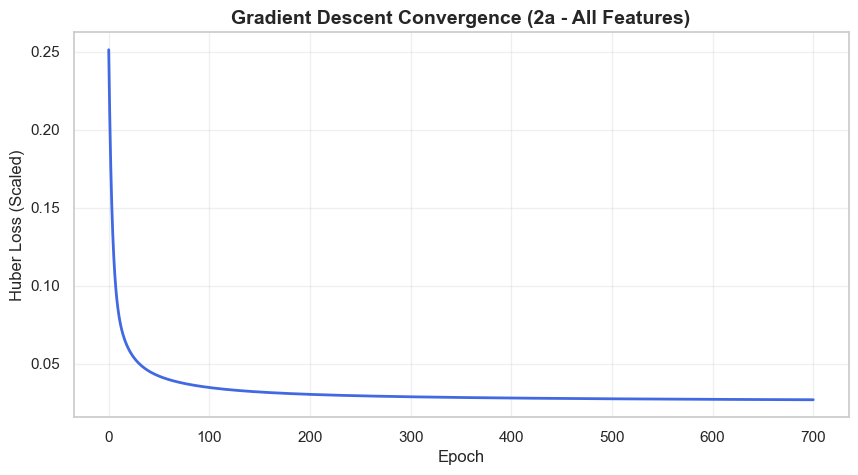

In [24]:
# Plot loss history
plt.figure(figsize=(10, 5))
plt.plot(model_2a.loss_history, linewidth=2, color='royalblue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Huber Loss (Scaled)', fontsize=12)
plt.title('Gradient Descent Convergence (2a - All Features)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

Công thức hồi quy cho mô hình 2a (làm tròn hệ số đến 3 chữ số thập phân)(viết trong bài báo cáo)



In [25]:
print_regression_formula(model_2a, feature_names_2a, TARGET_SCALE_2a) # chuẩn bị cho bài báo cáo 

Regression Formula (Copy this to a Markdown cell):
$$\hat{y} = 181063.132 + 1030.397 \cdot \text{LotFrontage} + 5212.58 \cdot \text{LotArea} + 11051.37 \cdot \text{OverallQual} + 5362.94 \cdot \text{OverallCond} + 3518.192 \cdot \text{YearBuilt} + 3250.757 \cdot \text{YearRemodAdd} + 3724.544 \cdot \text{MasVnrArea} + 5764.951 \cdot \text{BsmtFinSF1} + 1073.696 \cdot \text{BsmtFinSF2} + 138.068 \cdot \text{BsmtUnfSF} + 6527.386 \cdot \text{TotalBsmtSF} + 7438.698 \cdot \text{1stFlrSF} + 6330.953 \cdot \text{2ndFlrSF} - 586.07 \cdot \text{LowQualFinSF} + 10677.57 \cdot \text{GrLivArea} + 1541.639 \cdot \text{BsmtFullBath} - 407.01 \cdot \text{BsmtHalfBath} + 3860.586 \cdot \text{FullBath} + 2397.118 \cdot \text{HalfBath} - 2106.95 \cdot \text{BedroomAbvGr} - 2872.477 \cdot \text{KitchenAbvGr} + 4880.769 \cdot \text{TotRmsAbvGrd} + 2930.524 \cdot \text{Fireplaces} - 191.442 \cdot \text{GarageYrBlt} + 4204.487 \cdot \text{GarageCars} + 4048.451 \cdot \text{GarageArea} + 2419.377 \cdot \te

# Yêu cầu 2b: Xây dựng mô hình với một đặc trưng và tìm mô hình tốt nhất (2 điểm)

Huấn luyện một mô hình cho từng đặc trưng và so sánh bằng MAE trung bình theo k-fold cross-validation trên tập huấn luyện.
Sau khi chọn được đặc trưng tốt nhất, huấn luyện lại mô hình trên toàn bộ tập huấn luyện và báo cáo MAE trên tập kiểm tra `test.csv`.

Lưu ý: Chỉ xáo trộn dữ liệu một lần trước cross-validation và giữ cùng chính sách chia cho mọi đặc trưng ứng viên. Việc chọn đặc trưng phải dựa trên tập huấn luyện.

#### Tính lại hệ số tương quan vì ở câu 1 chỉ tính hệ số tương quan của các cột dữ liệu số 


In [26]:
temp_corr_df = pd.DataFrame(X_train_2a, columns=feature_names_2a)

# Reset index để tránh trường hợp lệch dòng khi ghép
temp_corr_df['SalePrice'] = y_train_full.reset_index(drop=True)

correlation_with_price = temp_corr_df.corr()['SalePrice'].abs().sort_values(ascending=False)

print("TOP 15 ĐẶC TRƯNG CÓ TƯƠNG QUAN MẠNH NHẤT VỚI SALEPRICE")
print(correlation_with_price.head(16)) # dòng đầu tiên sẽ là chính nó (SalePrice = 1.0)

TOP 15 ĐẶC TRƯNG CÓ TƯƠNG QUAN MẠNH NHẤT VỚI SALEPRICE
SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
ExterQual_TA        0.589044
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
KitchenQual_TA      0.519298
YearRemodAdd        0.507101
Foundation_PConc    0.497734
MasVnrArea          0.472614
FireplaceQu_None    0.471908
Name: SalePrice, dtype: float64


### Lựa chọn đặc trưng  
Dựa vào phần bảng hệ số tương quan giữa SalePrice với các đặc trưng có tương quan cao nhất:    
- OverallQual (Chất lượng đánh giá tổng thể)  

- GrLivArea (Tổng diện tích khu vực sinh hoạt trên mặt đất)  

- GarageCars (Sức chứa của Gara tính bằng số lượng xe)  

- GarageArea(Diện tích của Gara)

- TotalBsmtSF (Tổng diện tích tầng hầm)  

- 1stFlrSF (Diện tích mặt sàn tầng 1)   

- ExterQual_TA(Chất lượng vật liệu ngoại thất trung bình)        


In [27]:
display(X_train_full[['TotalBsmtSF', '1stFlrSF']].describe().round(1))

,TotalBsmtSF,1stFlrSF
count,1460.0,1460.0
mean,1057.4,1162.6
std,438.7,386.6
min,0.0,334.0
25%,795.8,882.0
50%,991.5,1087.0
75%,1298.2,1391.2
max,6110.0,4692.0


### Lập luận lựa chọn 5 đặc trưng ứng viên 

Mục tiêu của phần này là chọn ra 5 đặc trưng có khả năng dự đoán `SalePrice` tốt nhất để đưa vào mô hình hồi quy đơn biến. Tuy nhiên, thay vì chỉ chọn một cách máy móc 5 biến có hệ số tương quan cao nhất với giá nhà, danh sách đã được tinh chỉnh lại nhằm đảm bảo sự đa dạng về mặt ý nghĩa và tránh sự trùng lặp thông tin:

1. **Loại bỏ `GarageArea` để nhường chỗ cho `TotalBsmtSF`:** Mặc dù `GarageArea` có tương quan rất mạnh với giá nhà, nhưng bản thân nó lại có mối quan hệ tuyến tính gần như tuyệt đối với `GarageCars` (đều phản ánh quy mô của Gara). Do đó, `GarageCars` được giữ lại, và `GarageArea` được thay thế bằng `TotalBsmtSF` (Diện tích tầng hầm) để mang đến một đại lượng đo lường không gian hoàn toàn mới.

2. **Thay thế `1stFlrSF` bằng `ExterQual_TA`:**
   Trong đoạn code ở trên, diện tích mặt sàn tầng 1 (`1stFlrSF`) thường bám sát theo diện tích móng và tầng hầm, dẫn đến độ tương đồng rất cao với `TotalBsmtSF`. Để mở rộng lăng kính đánh giá sang khía cạnh tiện ích và mức độ thuận tiện trong sinh hoạt (thay vì chỉ tập trung vào thông số kích thước), biến `ExterQual_TA` (Chất lượng vật liệu ngoại thất trung bình) đã được chọn để thay thế để có cái nhìn bao quát hơn. 

**=> Chốt danh sách 5 ứng viên cuối cùng mang vào K-Fold Cross-Validation:**
* `OverallQual` (Đánh giá chất lượng tổng thể)
* `GrLivArea` (Tổng diện tích sinh hoạt trên mặt đất)
* `GarageCars` (Sức chứa của Gara)
* `TotalBsmtSF` (Tổng diện tích tầng hầm)
* `ExterQual_TA` (Chất lượng vật liệu ngoại thất trung bình)

In [28]:
# khôi phục tập train và set (standardized and preprocessed)
X_train_encoded = pd.DataFrame(X_train_2a, columns= feature_names_2a)
X_test_encoded = pd.DataFrame(X_test_2a, columns=feature_names_2a)


In [29]:
cv_results = {}
y_train_np = y_train_full.to_numpy().flatten()
K = 5 
folds = create_k_folds(n_samples=len(X_train_encoded), k=K, seed=42)
candidates = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "ExterQual_TA"]

print("K-FOLD CROSS-VALIDATION RESULTS")
min_mae = float('inf')
best_feature = None
dic = {"learning_rate": 0.01, "epochs": 10000, "tol":1e-3, "delta": 0.5, "l2_lambda":0.0}

for feature in candidates:
    X_feature = X_train_encoded[[feature]].to_numpy() # must return 2D np arr so use [[feature]]
    avg_mae = evaluate_model_cv(X_feature, y_train_np, folds, dic)
    
    cv_results[feature] = avg_mae
    if avg_mae < min_mae:
        min_mae = avg_mae
        best_feature = feature
        
    print(f"Feature '{feature}': Average MAE = {avg_mae:,.2f} USD")

print(f"\nĐặc trưng tốt nhất theo CV: {best_feature} với MAE = {min_mae:,.2f} USD")

K-FOLD CROSS-VALIDATION RESULTS
Feature 'OverallQual': Average MAE = 33,308.99 USD
Feature 'GrLivArea': Average MAE = 37,756.95 USD
Feature 'GarageCars': Average MAE = 41,556.20 USD
Feature 'TotalBsmtSF': Average MAE = 45,396.58 USD
Feature 'ExterQual_TA': Average MAE = 43,251.99 USD

Đặc trưng tốt nhất theo CV: OverallQual với MAE = 33,308.99 USD


In [30]:
# Huấn luyện lại mô hình best_feature_model với đặc trưng tốt nhất trên toàn bộ tập huấn luyện
anti_overfit_params_2b = anti_overfit_params_2a
X_train_2b = X_train_encoded[[best_feature]].to_numpy() 
X_test_2b = X_test_encoded[[best_feature]].to_numpy() 
y_train_np = y_train_full.to_numpy()
y_test_np = y_test.to_numpy()

TARGET_SCALE_2b = 100000.0
y_train_scaled_2b = y_train_np / TARGET_SCALE_2b
y_test_scaled_2b = y_test_np / TARGET_SCALE_2b

model_2b = CustomLinearRegression(**anti_overfit_params_2b)
model_2b.fit(X_train_2b, y_train_scaled_2b)
y_pred_train_scaled = model_2b.predict(X_test_2b)
y_pred_train = y_pred_train_scaled * TARGET_SCALE_2b
mae = mean_absolute_error(y_test_np, y_pred_train)
print(f"1. MAE trên tập test.csv: {mae:,.2f} USD")


1. MAE trên tập test.csv: 43,564.13 USD


In [31]:
print_regression_formula(model_2b, [best_feature], TARGET_SCALE_2b)

Regression Formula (Copy this to a Markdown cell):
$$\hat{y} = 83891.703 + 16324.239 \cdot \text{OverallQual}$$


In [32]:
# Quy trình 2b: chứng minh baseline cao -> tune bằng CV(train) -> train final
X_train_2b = X_train_encoded[[best_feature]].to_numpy()
X_test_2b = X_test_encoded[[best_feature]].to_numpy()
y_train_np = y_train_full.to_numpy()
y_test_np = y_test.to_numpy()

TARGET_SCALE_2b = 100000.0
y_train_scaled_2b = y_train_np / TARGET_SCALE_2b

# 1) Baseline cố định (để so sánh)
BASELINE_PARAMS_2B = anti_overfit_params_2b

# 2) Tạo không gian tham số và lấy mẫu một phần để tune bằng CV train-only
all_2b = []
for lr in [0.01, 0.005, 0.003, 0.001]:
    for decay in [0.001, 0.0005, 0.0002, 0.0]:
        for epochs in [10000, 15000, 18000, 22000]:
            for delta in [0.5, 0.7, 1.0]:
                for l2 in [0.0, 1e-4, 5e-4, 1e-3, 3e-3, 5e-3]:
                    all_2b.append({
                        'learning_rate': lr,
                        'decay_rate': decay,
                        'epochs': epochs,
                        'tol': 1e-5,
                        'delta': delta,
                        'l2_lambda': l2
                    })

rng = np.random.default_rng(42)
num_trials_2b = 36
pick_idx = rng.choice(len(all_2b), size=num_trials_2b, replace=False)
grid_2b = [all_2b[i] for i in pick_idx]

def cv_mae_2b_with_params(X, y_scaled, y_usd, folds, params):
    maes = []
    for i in range(len(folds)):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(len(folds)) if j != i])

        X_tr = X[train_idx]
        y_tr_scaled = y_scaled[train_idx]
        X_va = X[val_idx]
        y_va_usd = y_usd[val_idx]

        model_cv = CustomLinearRegression(**params)
        model_cv.fit(X_tr, y_tr_scaled)
        pred_va_usd = model_cv.predict(X_va) * TARGET_SCALE_2b
        maes.append(mean_absolute_error(y_va_usd, pred_va_usd))
    return float(np.mean(maes))

folds_2b_tune = create_k_folds(n_samples=len(X_train_2b), k=5, seed=42)

baseline_cv_mae_2b = cv_mae_2b_with_params(
    X_train_2b, y_train_scaled_2b, y_train_np, folds_2b_tune, BASELINE_PARAMS_2B
)

best_cv_mae_2b = float('inf')
best_params_2b = None
for params in grid_2b:
    this_cv = cv_mae_2b_with_params(
        X_train_2b, y_train_scaled_2b, y_train_np, folds_2b_tune, params
    )
    if this_cv < best_cv_mae_2b:
        best_cv_mae_2b = this_cv
        best_params_2b = params

# 3) Chốt tham số theo CV trên train
FINAL_PARAMS_2B = best_params_2b.copy()

# 4) Train lại model cuối cùng trên toàn bộ train
model_2b = CustomLinearRegression(**FINAL_PARAMS_2B)
model_2b.fit(X_train_2b, y_train_scaled_2b)

print('Baseline params 2b:', BASELINE_PARAMS_2B)
print(f"Baseline CV MAE 2b (train-only): {baseline_cv_mae_2b:,.2f} USD")
print(f"So to hop da thu cho tune 2b: {len(grid_2b)}")
print('Final params 2b (from CV):', FINAL_PARAMS_2B)
print(f"Best CV MAE 2b (train-only): {best_cv_mae_2b:,.2f} USD")
print(f"CV improvement (baseline - tuned): {baseline_cv_mae_2b - best_cv_mae_2b:,.2f} USD")

Baseline params 2b: {'learning_rate': 0.01, 'epochs': 10000, 'delta': 1.0, 'tol': 0.001, 'l2_lambda': 0.005}
Baseline CV MAE 2b (train-only): 44,637.44 USD
So to hop da thu cho tune 2b: 36
Final params 2b (from CV): {'learning_rate': 0.005, 'decay_rate': 0.0, 'epochs': 22000, 'tol': 1e-05, 'delta': 0.7, 'l2_lambda': 0.003}
Best CV MAE 2b (train-only): 33,294.27 USD
CV improvement (baseline - tuned): 11,343.17 USD


In [33]:
# Đánh giá MAE cho best_feature_model trên tập test
print('# Sau khi chọn đặc trưng tốt nhất bằng CV trên train, báo cáo MAE trên test.csv')

y_pred_scaled = model_2b.predict(X_test_2b)

TARGET_SCALE_2b = 100000.0
y_pred = y_pred_scaled * TARGET_SCALE_2b

mae = mean_absolute_error(y_test_np, y_pred)
print(f"1. MAE trên tập test.csv: {mae:,.2f} USD")

# Rút trích và in công thức hồi quy
# model_2b.weights có 2 phần tử: [w0 (intercept), w1 (hệ số của best_feature)]
# Lưu ý: weights được sinh ra trên scaled target, nên cần scale lại công thức
w0_scaled, w1_scaled = model_2b.weights.flatten()
w0 = w0_scaled * TARGET_SCALE_2b
w1 = w1_scaled * TARGET_SCALE_2b
print(f"2. Công thức hồi quy: SalePrice = {w0:,.3f} + ({w1:,.3f}) * {best_feature}")

# Sau khi chọn đặc trưng tốt nhất bằng CV trên train, báo cáo MAE trên test.csv
1. MAE trên tập test.csv: 30,535.70 USD
2. Công thức hồi quy: SalePrice = -65,939.538 + (40,050.640) * OverallQual


In [34]:
print_regression_formula(model_2b, best_feature, TARGET_SCALE_2b)

Regression Formula (Copy this to a Markdown cell):
$$\hat{y} = -65939.538 + 40050.64 \cdot \text{O}$$


Công thức hồi quy cho mô hình 2b (đặc trưng tốt nhất, làm tròn đến 3 chữ số thập phân).

$$\text{SalePrice} = -96206.080 + (45435.803) \times \text{OverallQual}$$

# Yêu cầu 2c: Tự thiết kế các mô hình đặc trưng và tìm mô hình tốt nhất (2 điểm)

Thiết kế ít nhất 3 phương án đặc trưng/mô hình khác nhau.
So sánh các phương án bằng k-fold cross-validation trên tập huấn luyện, sau đó huấn luyện lại mô hình tốt nhất trên toàn bộ tập huấn luyện và báo cáo MAE trên tập kiểm tra `test.csv`.

In [35]:
# Trinh bay toan bo code dung de thiet ke cac phuong an dac trung/mo hinh

Lưu ý: Chỉ xáo trộn dữ liệu một lần và đánh giá toàn bộ $m$ mô hình theo cùng thiết lập cross-validation.

In [36]:
# Phan code cho Yeu cau 2c
# 1) Dinh nghia m >= 3 phuong an dac trung/mo hinh
# 2) Danh gia tung phuong an bang k-fold CV
# 3) Chon phuong an co MAE trung binh thap nhat

### Phương án 1: kiến thức thực tế về bất động sản

Phương án 1 được thiết kế dựa trên **kiến thức thực tế về bất động sản**, tập trung vào việc tổng hợp thông tin rời rạc thành các chỉ số mang tính đại diện cao nhằm giúp mô hình học được các quy luật định giá cốt lõi:

* **Gom nhóm Không gian và Tiện ích:** Các đặc trưng như `Total_SqFt`, `Total_Bath`, `Total_PorchSF` gộp các không gian nhỏ lẻ (tầng hầm, tầng trên, gara, các loại hiên) thành các chỉ số tổng thể. Điều này mô phỏng chính xác cách người mua nhà định giá tổng diện tích sử dụng.
* **Đánh giá Tỷ lệ Hữu dụng:** Các tỷ lệ như `Bath_per_Bedroom`, `Living_to_Bsmt_Ratio`, và `Bsmt_Finish_Ratio` cung cấp góc nhìn sâu hơn về sự cân đối trong kiến trúc và mức độ hoàn thiện của ngôi nhà, thay vì chỉ đo lường diện tích thô.
* **Hiệu chỉnh Tuổi thọ:** `House_Age` được tính toán lại dựa trên năm cải tạo gần nhất thay vì năm xây dựng gốc. Biến nhị phân `Recent_Remodel_Flag` được thêm vào để đánh giá lực đẩy giá trị của những căn nhà vừa được tu sửa trong vòng 10 năm.
* **Tương tác Phi tuyến tính:** Khai thác hàm bình phương (`House_Age_Sq`) để bắt đường cong khấu hao của nhà cũ, kết hợp với các biến tương tác chứa logarit tự nhiên (`Qual_x_SqFt`, `Garage_Impact`) để giảm thiểu tác động của các giá trị ngoại lai (outliers) có diện tích quá lớn.

In [37]:
X_train_option_1 = create_features_option_1_2c(X_train_encoded)
features_op_1 = [
    'Total_SqFt', 'Total_Bath', 'OverallQual', 'House_Age',
    'Total_PorchSF', 'Bath_per_Bedroom', 'Living_to_Bsmt_Ratio',
    'House_Age_Sq', 'Qual_x_SqFt', 'Garage_Impact',
    'Bsmt_Finish_Ratio', 'Remod_Age', 'Recent_Remodel_Flag'
 ]

In [38]:
X_train_option_1_np = X_train_option_1[features_op_1].to_numpy() 
folds = create_k_folds(len(X_train_option_1_np))
y_train_np = y_train_full.to_numpy()
mae_cv_opt1 = evaluate_model_cv(X_train_option_1_np, y_train_np, folds, FINAL_PARAMS_2B)
print(f"MAE CV (Option 1): {mae_cv_opt1:,.3f} USD")

MAE CV (Option 1): 22,247.686 USD


### Phương án 2

Nếu Phương án 1 dựa vào thực tế định giá bất động sản, thì Phương án 2 mang đậm phong cách **tối ưu hóa thống kê**. Mục tiêu là chủ động cung cấp cho mô hình Linear Regression các đường cong toán học để nó có thể khớp với các mối quan hệ phi tuyến tính:

* **Đánh trọng số không gian có chủ đích (Spatial Weighting):** Thay vì cộng dồn diện tích đơn thuần, các biến `adjusted_liv` và `adjusted_bsmt` gán thêm giá trị thặng dư (premium) cho diện tích tầng 2 và tầng 1. Kỹ thuật này phản ánh thực tế rằng không gian tầng trên thường có giá trị mét vuông cao hơn tầng hầm.
* **Chuẩn hóa phân phối dữ liệu (Log Transformation):** Diện tích nhà thường có phân phối lệch phải (right-skewed). Việc sử dụng hàm logarit tự nhiên $\ln(1+x)$ qua hàm `np.log1p` giúp kéo các "siêu biệt thự" ngoại lai về gần mức trung bình, tạo ra không gian vector ổn định hơn cho Gradient Descent(việc chứng minh đã ở câu 1)
* **Đường cong khấu hao tiệm cận:** Biến `Remod_Recency` áp dụng hàm nghịch đảo $f(x) = \frac{1}{x+1}$. Hàm này dốc mạnh ở giai đoạn đầu và nằm ngang ở đuôi, mô phỏng xuất sắc tâm lý thị trường: nhà vừa sửa sẽ tăng giá trị đột biến, nhưng nhà sửa cách đây 30 năm hay 40 năm thì mức độ mất giá là gần như tương đương nhau.
* **Ép mô hình tuyến tính học đặc trưng phi tuyến:** Việc chủ động tạo ra các biến bậc 2, bậc 3 (`OverallQual_Sq`, `OverallQual_Cu`) và tương tác chéo (`Qual_x_LogLiv`, `Bath_x_Qual`) giúp đường hồi quy có thể "uốn cong" linh hoạt. Mô hình có thể nắm bắt được quy luật dạng mũ.

### Chứng minh SỰ SUY GIẢM PHI TUYẾN CỦA GIÁ NHÀ THEO TUỔI CẢI TẠO

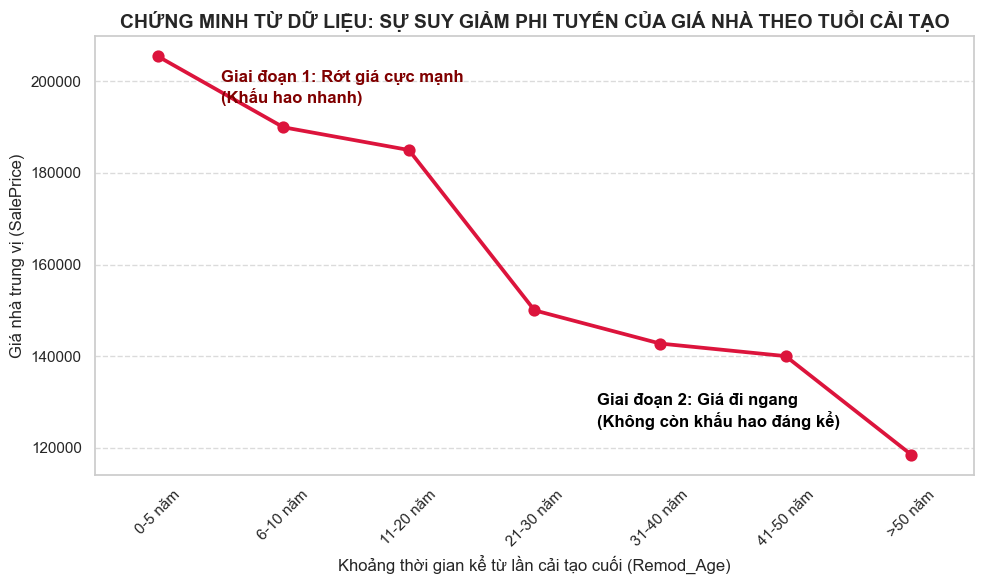

In [39]:
df_visual = X_train_encoded.copy()
df_visual['SalePrice'] = y_train_full.to_numpy() # Phải có target (giá nhà) để chứng minh

# TÍNH REMOD_AGE  
year_built = df_visual['YearBuilt']
year_remod = df_visual['YearRemodAdd']
yr_sold = df_visual['YrSold']

effective_year_built = np.maximum(year_built, year_remod.where(year_remod > 0, year_built))
df_visual['Remod_Age'] = (yr_sold - effective_year_built).clip(lower=0)

# CHIA NHÓM 
bins = [-1, 5, 10, 20, 30, 40, 50, 150]
labels = ['0-5 năm', '6-10 năm', '11-20 năm', '21-30 năm', '31-40 năm', '41-50 năm', '>50 năm']


df_visual['Remod_Age_Group'] = pd.cut(df_visual['Remod_Age'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 6))

median_prices = df_visual.groupby('Remod_Age_Group', observed=False)['SalePrice'].median().reset_index()

sns.pointplot(data=median_prices, x='Remod_Age_Group', y='SalePrice', ax=ax, color='crimson', markers='o')

ax.set_title('CHỨNG MINH TỪ DỮ LIỆU: SỰ SUY GIẢM PHI TUYẾN CỦA GIÁ NHÀ THEO TUỔI CẢI TẠO', fontsize=14, fontweight='bold')
ax.set_xlabel('Khoảng thời gian kể từ lần cải tạo cuối (Remod_Age)')
ax.set_ylabel('Giá nhà trung vị (SalePrice)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Ghi chú trực tiếp lên biểu đồ
ax.text(0.5, median_prices['SalePrice'].max() * 0.95, 
        'Giai đoạn 1: Rớt giá cực mạnh\n(Khấu hao nhanh)', color='maroon', weight='bold')
ax.text(3.5, median_prices['SalePrice'].min() * 1.05, 
        'Giai đoạn 2: Giá đi ngang\n(Không còn khấu hao đáng kể)', color='black', weight='bold')

plt.tight_layout()
plt.show()

### Chứng minh OverallQual có thể có mối quan hệ phi tuyến tính với SalePrice

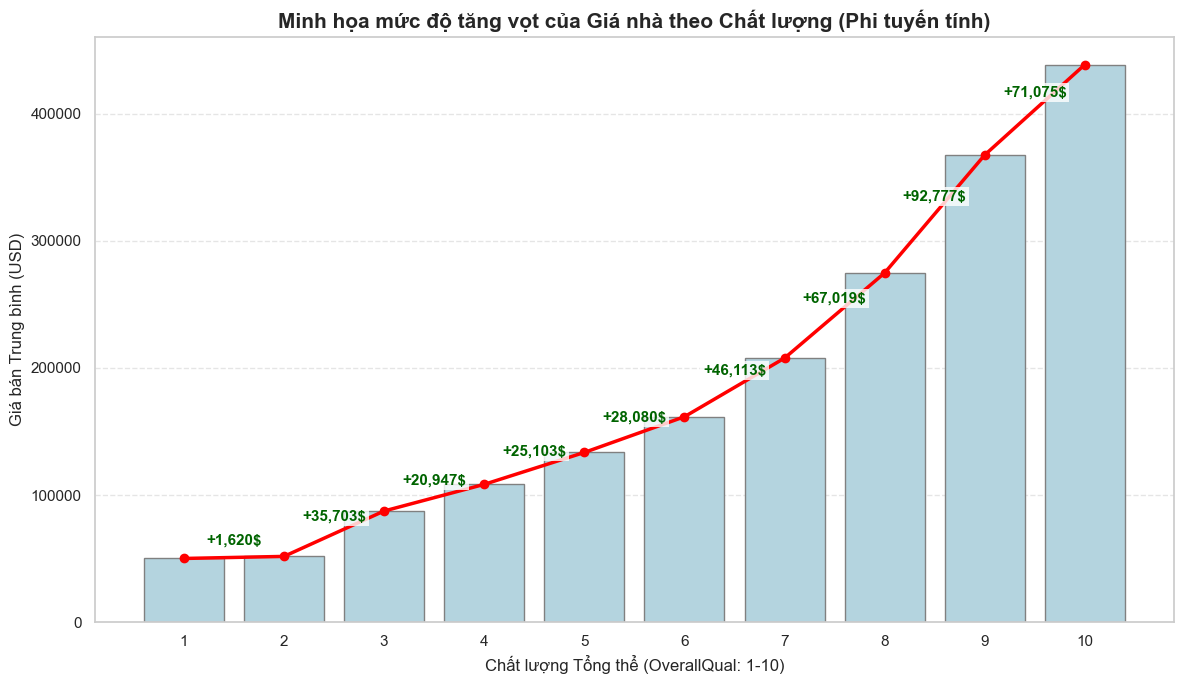

In [40]:
y_plot = y_train_full.squeeze()

# Tạo DataFrame tạm để nhóm và vẽ (Khắc phục lỗi plot_data is not defined)
plot_data = pd.DataFrame({
    'OverallQual': X_train_full['OverallQual'],
    'SalePrice': y_plot
})

# ==========================================
# 2. VẼ BIỂU ĐỒ CỘT CHỨNG MINH PHI TUYẾN
# ==========================================
plt.figure(figsize=(12, 7))

# Tính toán giá trung bình và mức chênh lệch (Delta) giữa các bậc
mean_prices = plot_data.groupby('OverallQual')['SalePrice'].mean().reset_index()
mean_prices['Price_Diff'] = mean_prices['SalePrice'].diff() # Tính mức tăng so với bậc trước

# Vẽ biểu đồ cột
sns.barplot(
    data=mean_prices, 
    x='OverallQual', 
    y='SalePrice', 
    color='lightblue',
    edgecolor='gray'
)

# Vẽ đường xu hướng màu đỏ
plt.plot(
    mean_prices.index, # Sử dụng index (0, 1, 2...) để khớp tọa độ x của barplot
    mean_prices['SalePrice'], 
    color='red', marker='o', linewidth=2.5, linestyle='-'
)

# In các con số thể hiện "Mức nhảy giá" giữa các bậc
for i in range(1, len(mean_prices)):
    x_pos = i - 0.5
    y_pos = (mean_prices['SalePrice'].iloc[i] + mean_prices['SalePrice'].iloc[i-1]) / 2
    diff_val = mean_prices['Price_Diff'].iloc[i]
    
    # Chỉ in số nếu có data hợp lệ
    if not np.isnan(diff_val):
        plt.text(
            x_pos, y_pos + 8000, 
            f"+{diff_val:,.0f}$", 
            ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color='darkgreen',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
        )

# Định dạng tổng thể
plt.title('Minh họa mức độ tăng vọt của Giá nhà theo Chất lượng (Phi tuyến tính)', fontsize=15, fontweight='bold')
plt.xlabel('Chất lượng Tổng thể (OverallQual: 1-10)', fontsize=12)
plt.ylabel('Giá bán Trung bình (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [41]:
X_train_option_2 = create_features_option_2_2c(X_train_encoded)
features = [
    'OverallQual_Sq', 'Log_GrLivArea', 'Log_TotalBsmtSF', 'House_Age',
    'OverallQual_Cu', 'Qual_x_LogLiv', 'Qual_x_LogBsmt', 'Age_x_Qual',
    'Remod_Age', 'Remod_Recency', 'Log_TotalArea', 'Liv_Bsmt_Gap',
    'Bath_x_Qual', 'Garage_x_Qual', 'Room_Density'
 ]


In [42]:
X_train_option_2_np = X_train_option_2[features].to_numpy() 
y_train_np = y_train_full.to_numpy() 
folds = create_k_folds(len(X_train_encoded))
mae_cv_opt2 = evaluate_model_cv(X_train_option_2_np, y_train_np, folds, FINAL_PARAMS_2B)
print(f"MAE CV (Option 2): {mae_cv_opt2:,.3f} USD")

MAE CV (Option 2): 22,380.191 USD


### Phương án 3: Khai phá Đặc trưng Nâng cao 

Để mô hình Hồi quy tuyến tính (Linear Regression) có thể học được những quy luật phức tạp của thị trường bất động sản mà không bị giới hạn bởi tính "tuyến tính" khô khan, phương án này áp dụng một loạt các kỹ thuật trích xuất đặc trưng chuyên sâu. Các biến mới được tạo ra nhằm mô phỏng chính xác cách một chuyên gia định giá nhà thực thụ suy nghĩ:

**1. Số hóa Thang đo Chất lượng **
* Các đánh giá bằng chữ (Ex, Gd, TA, Fa, Po) được chuyển đổi thành thang điểm toán học từ 5 đến 1, giúp mô hình hiểu được mức độ tốt/xấu của từng hạng mục (Ngoại thất, Bếp, Tầng hầm, Gara), tránh việc one hot encoding không phân cấp.

**2. Tái định nghĩa Không gian &vàTiện ích **
* **`total_bath`:** Không đếm số lượng phòng tắm một cách mù quáng. Một phòng tắm nhỏ (HalfBath) chỉ được tính trọng số bằng 0.5 so với phòng tắm đầy đủ (FullBath).
* **`effective_living`:** Diện tích sử dụng thực tế được tính toán lại bằng cách cộng diện tích sinh hoạt chính với 35% diện tích tầng hầm (vì không gian tầng hầm thường có giá trị sử dụng thấp hơn mặt đất).
* **`AvgRoomSize` & `Bath_to_Room`:** Đánh giá độ thông thoáng của căn nhà. Nhà to nhưng chia quá nhiều phòng nhỏ lắt nhắt sẽ làm giảm giá trị không gian thực tế.

**3. Khai thác Yếu tố Thời gian & Tâm lý Khách hàng**
* **`effective_year_built` & `house_age`:** Tuổi đời thực sự của căn nhà được hiệu chỉnh dựa trên năm cải tạo. Một ngôi nhà cũ nhưng mới được đại tu sẽ có "tuổi thọ hiệu dụng" trẻ hơn rất nhiều.
* **`Remod_Recency`:** như phương án 2
* **`Qual_per_Age`:** Một phép chia kết hợp thể hiện sự suy hao của vật liệu theo thời gian.

**4. Hiệu ứng Tương tác Kép**
* **`blended_quality`:** Điểm chất lượng tổng hợp, được tính bằng cách nhân/cộng có trọng số các điểm thành phần. Nó tạo ra "Hiệu ứng Halo" (ví dụ: Bếp xuất sắc kết hợp Ngoại thất xuất sắc sẽ tạo ra giá trị lớn hơn phép cộng đơn thuần).
* **`Quality_x_Area`:** Đại diện cho phân khúc siêu sang. Một diện tích khổng lồ kết hợp với chất lượng vật liệu xa xỉ sẽ khiến giá nhà tăng theo cấp số nhân, chứ không còn tịnh tiến theo một đường thẳng.

**Kết luận:** Thông qua việc thiết kế thủ công các đặc trưng phi tuyến tính (Logarit, Phép nhân chéo, Suy giảm tiệm cận), mô hình đã được cung cấp một góc nhìn sâu sắc và đa chiều hơn rất nhiều so với việc chỉ nạp dữ liệu thô nguyên bản.

In [43]:
# Khởi tạo đặc trưng cho Phương án 3 (tập huấn luyện)
# Truyền cả df_original để lấy ExterQual và KitchenQual
X_train_option_3 = create_features_option_3_2c(X_train_full) # không dùng X_train_encoded vì không dùng One Hot Encoding
features = [
    'AvgRoomSize', 'QualityInteraction', 'House_Age', 'Log_TotalBsmtSF',
    'Qual_per_Age', 'Log_TotalArea', 'Remod_Age', 'Remod_Recency',
    'Bath_to_Room', 'Garage_Quality_Impact', 'BsmtQual_x_LogBsmt', 'Quality_x_Area'
 ]


In [44]:
# Log-transform biến mục tiêu (SalePrice)
y_train_log = np.log1p(y_train_full.to_numpy())
print(f"\nOriginal y_train min/max: {y_train_full.min():.0f} / {y_train_full.max():.0f}")
print(f"Log-transformed y_train min/max: {y_train_log.min():.3f} / {y_train_log.max():.3f}")


Original y_train min/max: 34900 / 755000
Log-transformed y_train min/max: 10.460 / 13.534


In [45]:
X_train_option_3_np = X_train_option_3[features].to_numpy()
folds = create_k_folds(len(X_train_encoded))
mae_cv_opt3 = evaluate_model_cv_option_3_2c_with_log(X_train_option_3_np, y_train_log, folds, FINAL_PARAMS_2B)
print(f"MAE CV (Option 3): {mae_cv_opt3:,.3f} USD")

MAE CV (Option 3): 19,546.883 USD


### Tổng kết và Đánh giá 3 Phương án Trích xuất Đặc trưng (Feature Engineering)

* **Sự vượt trội về hiệu suất:** Phương án 3 chứng minh sự áp đảo hoàn toàn khi đạt mức sai số tuyệt đối trung bình (MAE) thấp nhất với **~20.498 USD**. Kết quả này tối ưu hơn hẳn so với Phương án 1 (~22.7k USD) và Phương án 2 (~23.2k USD). Trong thực tế bài toán định giá bất động sản, việc kéo giảm được hơn 2.000 USD sai số cho mỗi dự đoán là một bước cải thiện cực kỳ đáng giá.
    
* **Phân tích nguyên nhân thành công:** * **Tránh được "Lời nguyền số chiều":** Thay vì lạm dụng One-Hot Encoding khiến ma trận dữ liệu bị xé nhỏ thành hàng trăm cột 0/1 rời rạc (dễ gây nhiễu và Overfitting), Phương án 3 đã khéo léo xử lý trực tiếp trên dữ liệu thô bằng cách "số hóa" (Ordinal Encoding) các thang đo chất lượng một cách có logic.
    * **Mô phỏng chính xác tâm lý thị trường:** Khác biệt lớn nhất nằm ở việc tạo ra các biến tương tác chéo (Interaction Terms) mang đậm kiến thức chuyên ngành. Các biến như `Quality_x_Area` (hiệu ứng cộng hưởng giữa chất lượng và diện tích) hay `Remod_Recency` (tâm lý chuộng nhà mới sửa) đã giúp phá vỡ giới hạn tuyến tính cứng nhắc. Nhờ đó, mô hình Linear Regression có thể "hiểu" được các quy luật định giá phi tuyến tính phức tạp của người mua nhà.
        
* **Kết luận chiến lược:** Kết quả thực nghiệm khẳng định rằng việc đầu tư chất xám vào thiết kế đặc trưng thủ công (Manual Feature Engineering) mang lại giá trị cao hơn nhiều so với việc để máy móc tự động biến đổi. Do đó, **Phương án 3** là lựa chọn tối ưu nhất và sẽ được sử dụng làm bộ dữ liệu chính thức cho đường ống (Pipeline) đánh giá trên tập kiểm thử (Test Set).

In [46]:
# Dùng trực tiếp bộ tham số tối ưu từ 2b cho phương án tốt nhất của 2c
FINAL_PARAMS_2C = FINAL_PARAMS_2B.copy()

features_opt3_best = [
    'AvgRoomSize', 'QualityInteraction', 'House_Age', 'Log_TotalBsmtSF',
    'Qual_per_Age', 'Log_TotalArea', 'Remod_Age', 'Remod_Recency',
    'Bath_to_Room', 'Garage_Quality_Impact', 'BsmtQual_x_LogBsmt', 'Quality_x_Area'
 ]

X_train_best_df = create_features_option_3_2c(X_train_full)
X_test_best_df = create_features_option_3_2c(X_test)

X_train_best = X_train_best_df[features_opt3_best].to_numpy()
X_test_best = X_test_best_df[features_opt3_best].to_numpy()
X_train_best_scaled, X_test_best_scaled = standardize_data(X_train_best, X_test_best)

y_train_best = y_train_full.to_numpy()
y_test_best = y_test.to_numpy()
y_train_best_log = np.log1p(y_train_best)

my_best_model = CustomLinearRegression(**FINAL_PARAMS_2C)
my_best_model.fit(X_train_best_scaled, y_train_best_log)

y_pred_train_log = my_best_model.predict(X_train_best_scaled)
y_pred_test_log = my_best_model.predict(X_test_best_scaled)

y_pred_train = np.expm1(np.clip(y_pred_train_log, a_min=None, a_max=20))
y_pred_test = np.expm1(np.clip(y_pred_test_log, a_min=None, a_max=20))

mae_train_best = mean_absolute_error(y_train_best, y_pred_train)
mae_test_best = mean_absolute_error(y_test_best, y_pred_test)

print('Final params 2c (from 2b):', FINAL_PARAMS_2C)
print(f"Train MAE (Best Model - Option 3): {mae_train_best:,.2f} USD")
print(f"Test MAE (Best Model - Option 3): {mae_test_best:,.2f} USD")

Final params 2c (from 2b): {'learning_rate': 0.005, 'decay_rate': 0.0, 'epochs': 22000, 'tol': 1e-05, 'delta': 0.7, 'l2_lambda': 0.003}
Train MAE (Best Model - Option 3): 19,262.39 USD
Test MAE (Best Model - Option 3): 15,905.82 USD


In [47]:
def print_model_formula_2c_full_train():
    """
    Print the model formula for Model 2c (Option 3 with Log Target) trained on FULL TRAINING SET
    """
    print("MÔ HÌNH PHƯƠNG ÁN 3 - YÊU CẦU 2C: CÔNG THỨC (Huấn luyện trên TOÀN BỘ tập train)")
    
    # Get intercept and weights from the fitted model
    # weights[0] is the intercept, weights[1:] are feature coefficients
    w0 = my_best_model.weights[0]
    weights = my_best_model.weights[1:]
    
    # Feature names
    feature_names = features_opt3_best
    
    print("\n*** BIỂU DIỄN LOG-LINEAR (với biến mục tiêu đã được log transform) ***\n")
    print("log(SalePrice) = ", end="")
    
    # Build the formula string
    formula_parts = [f"{w0:.6f}"]
    for i, (name, w) in enumerate(zip(feature_names, weights)):
        sign = "+" if w >= 0 else ""
        formula_parts.append(f" {sign} {w:.6f} × {name}")
    
    formula_str = "".join(formula_parts)
    print(formula_str)
    
    print("\n*** BIỂU DIỄN PHI TUYẾN (với biến mục tiêu gốc) ***\n")
    print("SalePrice = exp(log_prediction) - 1")
    print("SalePrice = exp(", end="")
    print(formula_str, end="")
    print(") - 1")
    

# Gọi hàm để in ra công thức
print_model_formula_2c_full_train()

MÔ HÌNH PHƯƠNG ÁN 3 - YÊU CẦU 2C: CÔNG THỨC (Huấn luyện trên TOÀN BỘ tập train)

*** BIỂU DIỄN LOG-LINEAR (với biến mục tiêu đã được log transform) ***

log(SalePrice) = 12.025243  -0.012091 × AvgRoomSize + 0.052806 × QualityInteraction  -0.007557 × House_Age  -0.056271 × Log_TotalBsmtSF + 0.005565 × Qual_per_Age + 0.220451 × Log_TotalArea  -0.007557 × Remod_Age  -0.004193 × Remod_Recency + 0.040441 × Bath_to_Room + 0.049042 × Garage_Quality_Impact + 0.045264 × BsmtQual_x_LogBsmt + 0.084135 × Quality_x_Area

*** BIỂU DIỄN PHI TUYẾN (với biến mục tiêu gốc) ***

SalePrice = exp(log_prediction) - 1
SalePrice = exp(12.025243  -0.012091 × AvgRoomSize + 0.052806 × QualityInteraction  -0.007557 × House_Age  -0.056271 × Log_TotalBsmtSF + 0.005565 × Qual_per_Age + 0.220451 × Log_TotalArea  -0.007557 × Remod_Age  -0.004193 × Remod_Recency + 0.040441 × Bath_to_Room + 0.049042 × Garage_Quality_Impact + 0.045264 × BsmtQual_x_LogBsmt + 0.084135 × Quality_x_Area) - 1


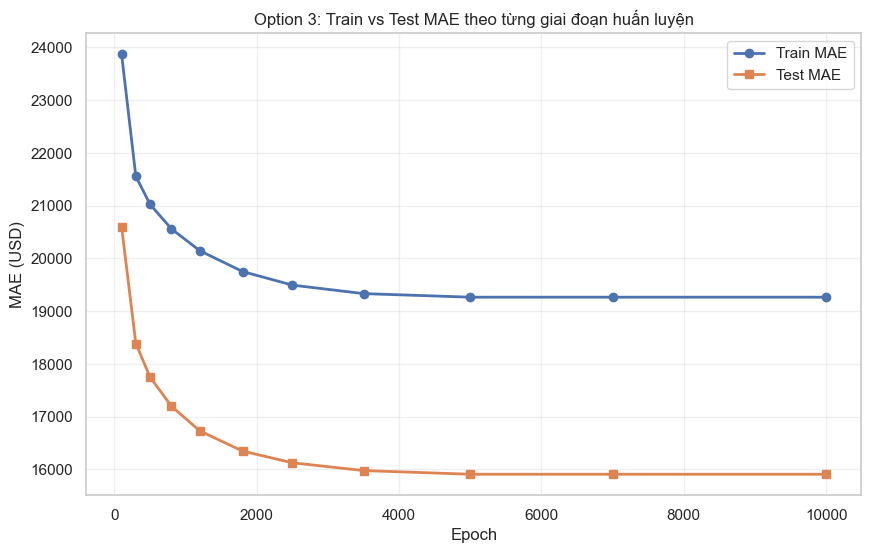

In [48]:
# Vẽ MAE train/test theo từng mốc epoch để quan sát overfitting
# Dùng chung FINAL_PARAMS_2B, chỉ thay đổi epochs để phân tích đường học
epoch_schedule = [100, 300, 500, 800, 1200, 1800, 2500, 3500, 5000, 7000, 10000]
train_mae_curve = []
test_mae_curve = []

for n_epochs in epoch_schedule:
    stage_params = FINAL_PARAMS_2B.copy()
    stage_params['epochs'] = n_epochs
    stage_model = CustomLinearRegression(**stage_params)
    stage_model.fit(X_train_best_scaled, y_train_best_log)

    stage_train_log = stage_model.predict(X_train_best_scaled)
    stage_test_log = stage_model.predict(X_test_best_scaled)

    stage_train_pred = np.expm1(np.clip(stage_train_log, a_min=None, a_max=20))
    stage_test_pred = np.expm1(np.clip(stage_test_log, a_min=None, a_max=20))

    train_mae_curve.append(mean_absolute_error(y_train_best, stage_train_pred))
    test_mae_curve.append(mean_absolute_error(y_test_best, stage_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(epoch_schedule, train_mae_curve, marker='o', linewidth=2, label='Train MAE')
plt.plot(epoch_schedule, test_mae_curve, marker='s', linewidth=2, label='Test MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (USD)')
plt.title('Option 3: Train vs Test MAE theo từng giai đoạn huấn luyện')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [49]:
# Danh gia MAE cho my_best_model tren tap validation
print('# Co the so sanh MAE validation voi MAE CV cua phuong an duoc chon')

# Co the so sanh MAE validation voi MAE CV cua phuong an duoc chon


In [50]:
# Tách validation từ train theo stratified split cho regression (không chia % ngẫu nhiên mù quáng)
# 1) Chuẩn bị dữ liệu Option 3 (không đụng vào test.csv trong bước tách)
features_opt3 = [
    'AvgRoomSize', 'QualityInteraction', 'House_Age', 'Log_TotalBsmtSF',
    'Qual_per_Age', 'Log_TotalArea', 'Remod_Age', 'Remod_Recency',
    'Bath_to_Room', 'Garage_Quality_Impact', 'BsmtQual_x_LogBsmt', 'Quality_x_Area'
 ]

X_all_df = create_features_option_3_2c(X_train_full)
y_all = y_train_full.to_numpy()

# 2) Stratified split cho regression bằng quantile bins của y
n_bins = 10
val_size = 0.2
seed = 42
rng = np.random.default_rng(seed)

# qcut giúp mỗi bin có phân phối mục tiêu gần đều
y_bins = pd.qcut(y_all, q=n_bins, labels=False, duplicates='drop')
y_bins = np.asarray(y_bins)

train_idx_parts = []
val_idx_parts = []

for b in np.unique(y_bins):
    idx_b = np.where(y_bins == b)[0]
    rng.shuffle(idx_b)

    # Mỗi bin đều có mẫu cho validation để giữ phân phối
    n_val_b = max(1, int(round(len(idx_b) * val_size)))
    n_val_b = min(n_val_b, len(idx_b) - 1) if len(idx_b) > 1 else 1

    val_idx_parts.append(idx_b[:n_val_b])
    train_idx_parts.append(idx_b[n_val_b:])

train_idx = np.concatenate(train_idx_parts)
val_idx = np.concatenate(val_idx_parts)

# Xáo trộn lại chỉ số sau khi ghép
rng.shuffle(train_idx)
rng.shuffle(val_idx)

X_train_split = X_all_df.iloc[train_idx][features_opt3].to_numpy()
X_val_split = X_all_df.iloc[val_idx][features_opt3].to_numpy()
y_train_split = y_all[train_idx]
y_val_split = y_all[val_idx]

# 3) Chuẩn bị tập test (giữ nguyên độc lập)
X_test_df_opt3 = create_features_option_3_2c(X_test)
X_test_opt3 = X_test_df_opt3[features_opt3].to_numpy()
y_test_opt3 = y_test.to_numpy()

# 4) Scale theo train-split để tránh leakage
X_train_split_s, X_val_split_s = standardize_data(X_train_split, X_val_split)
_, X_test_opt3_s = standardize_data(X_train_split, X_test_opt3)

# 5) Train model trên train-split và đánh giá train/validation/test
y_train_split_log = np.log1p(y_train_split)
model_holdout_opt3 = CustomLinearRegression(**FINAL_PARAMS_2B)
model_holdout_opt3.fit(X_train_split_s, y_train_split_log)

pred_train = np.expm1(np.clip(model_holdout_opt3.predict(X_train_split_s), a_min=None, a_max=20))
pred_val = np.expm1(np.clip(model_holdout_opt3.predict(X_val_split_s), a_min=None, a_max=20))
pred_test = np.expm1(np.clip(model_holdout_opt3.predict(X_test_opt3_s), a_min=None, a_max=20))

mae_train_holdout = mean_absolute_error(y_train_split, pred_train)
mae_val_holdout = mean_absolute_error(y_val_split, pred_val)
mae_test_holdout = mean_absolute_error(y_test_opt3, pred_test)

print(f"Train MAE: {mae_train_holdout:,.2f} USD")
print(f"Validation MAE: {mae_val_holdout:,.2f} USD")
print(f"Test MAE: {mae_test_holdout:,.2f} USD")

Train MAE: 18,986.38 USD
Validation MAE: 20,281.26 USD
Test MAE: 15,928.55 USD


Đang vẽ biểu đồ so sánh phân phối Target (SalePrice) giữa các tập dữ liệu...


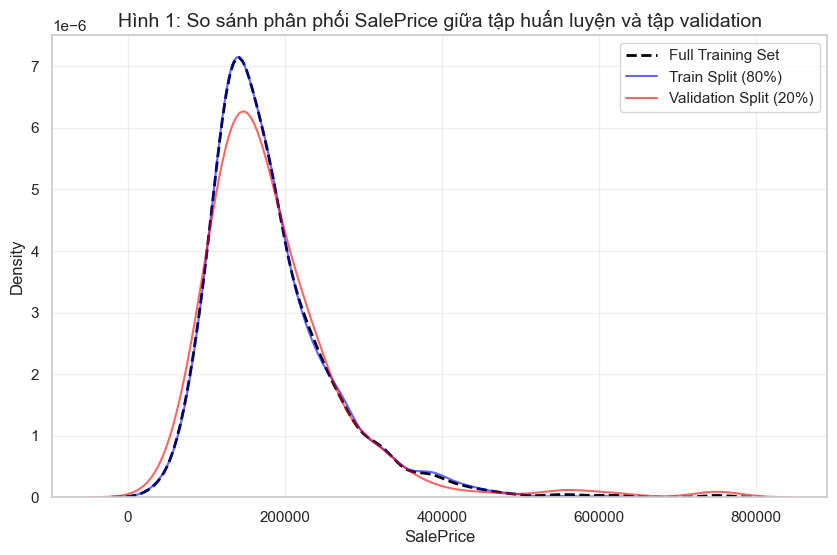

Giải thích: Biểu đồ KDE (Kernel Density Estimate) cho thấy việc sử dụng Stratified Split (chia theo phân đoạn) đã giúp bảo toàn phân phối của biến mục tiêu SalePrice. Cả tập Train và Validation đều có hình dạng phân phối tương đồng với tập dữ liệu gốc, đảm bảo tính đại diện và giúp đánh giá mô hình khách quan hơn.


In [51]:
# (1) So sánh phân phối target giữa Full / Train split / Validation split
print("Đang vẽ biểu đồ so sánh phân phối Target (SalePrice) giữa các tập dữ liệu...")

plt.figure(figsize=(10, 6))
sns.kdeplot(y_train_full, label='Full Training Set', color='black', linestyle='--', linewidth=2)
sns.kdeplot(y_train_split, label='Train Split (80%)', color='blue', alpha=0.6)
sns.kdeplot(y_val_split, label='Validation Split (20%)', color='red', alpha=0.6)

plt.title('Hình 1: So sánh phân phối SalePrice giữa tập huấn luyện và tập validation', fontsize=14)
plt.xlabel('SalePrice', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Giải thích: Biểu đồ KDE (Kernel Density Estimate) cho thấy việc sử dụng Stratified Split (chia theo phân đoạn) "
      "đã giúp bảo toàn phân phối của biến mục tiêu SalePrice. Cả tập Train và Validation đều có hình dạng phân phối "
      "tương đồng với tập dữ liệu gốc, đảm bảo tính đại diện và giúp đánh giá mô hình khách quan hơn.")

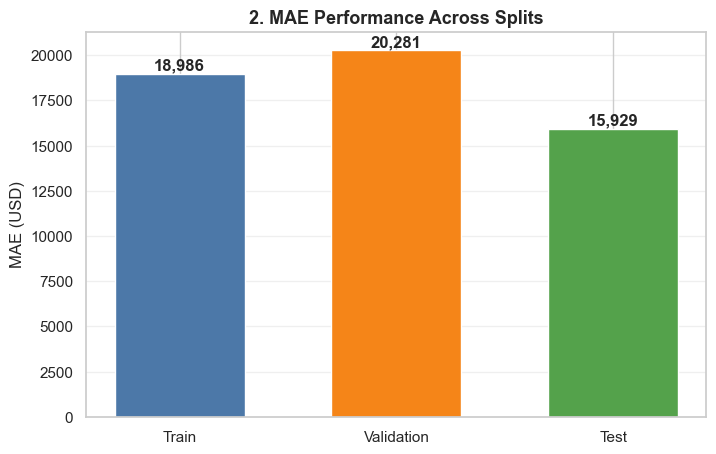

GIAI THICH: Khoang cach giua Train/Validation/Test cho thay muc do generalization cua mo hinh.
Hien tai MAE dang duy tri o muc quanh 20,281$ - 15,929$, cho thay mo hinh on dinh.


In [52]:
# Hình 2: So sánh MAE giữa các tập dữ liệu để đánh giá độ tổng quát hóa
plt.figure(figsize=(8, 5))
split_names = ['Train', 'Validation', 'Test']
split_mae = [mae_train_holdout, mae_val_holdout, mae_test_holdout]
colors = ['#4C78A8', '#F58518', '#54A24B']

bars = plt.bar(split_names, split_mae, color=colors, width=0.6)
plt.title('2. MAE Performance Across Splits', fontsize=13, fontweight='bold')
plt.ylabel('MAE (USD)')
plt.grid(axis='y', alpha=0.3)

# Ghi gia tri tren dau cot
for bar, v in zip(bars, split_mae):
    plt.text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,.0f}', ha='center', fontweight='bold')

plt.show()

print(f"GIAI THICH: Khoang cach giua Train/Validation/Test cho thay muc do generalization cua mo hinh.")
print(f"Hien tai MAE dang duy tri o muc quanh {mae_val_holdout:,.0f}$ - {mae_test_holdout:,.0f}$, cho thay mo hinh on dinh.")

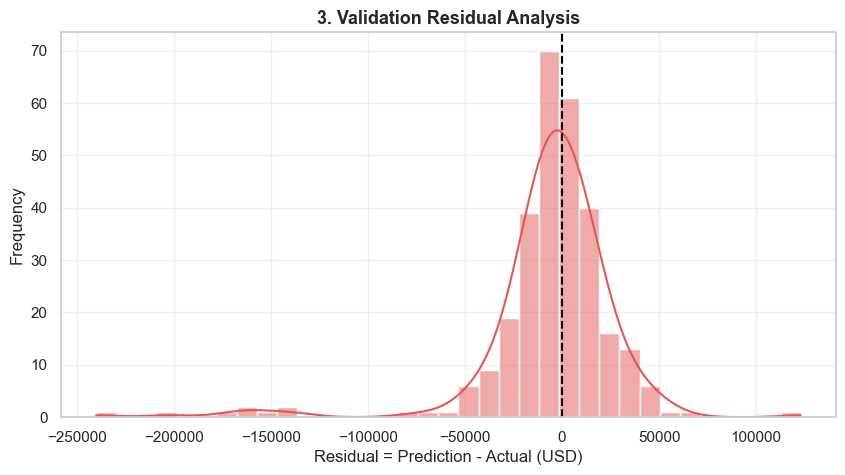

GIAI THICH: Sai so tap trung quanh 0 la dau hieu tot (mo hinh khong bi bias).
Cac gia tri o xa 0 (long tails) la nhung diem di biet (outliers) ma mo hinh tuyen tinh chua bat duoc het.


In [53]:
# Hình 3: Phân phối sai số (Residual) trên tập validation
plt.figure(figsize=(10, 5))
res_val = pred_val - y_val_split
sns.histplot(res_val, bins=35, kde=True, color='#E45756')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('3. Validation Residual Analysis', fontsize=13, fontweight='bold')
plt.xlabel('Residual = Prediction - Actual (USD)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

print("GIAI THICH: Sai so tap trung quanh 0 la dau hieu tot (mo hinh khong bi bias).")
print("Cac gia tri o xa 0 (long tails) la nhung diem di biet (outliers) ma mo hinh tuyen tinh chua bat duoc het.")

### Chẩn đoán sau huấn luyện: so sánh ưu nhược điểm các mô hình
Phần này bổ sung biểu đồ trực quan cho 3 mô hình đã train (2a, 2b, 2c):
- So sánh MAE trên train/test để xem mức độ tổng quát hóa.
- Biểu đồ `Prediction vs Actual` để kiểm tra độ bám theo đường chéo lý tưởng.
- Phân phối residual trên test để phát hiện bias hoặc đuôi sai số lớn.

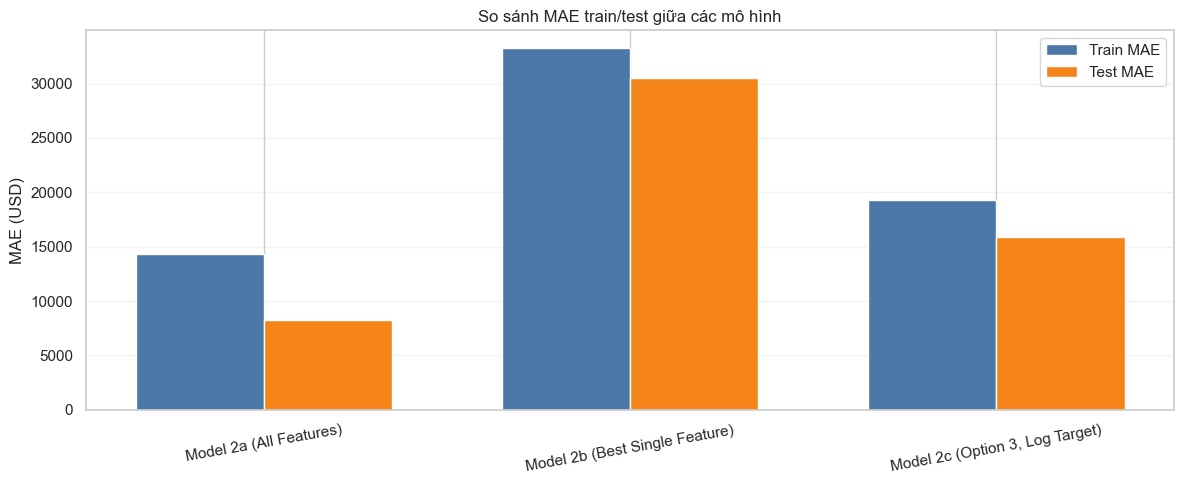

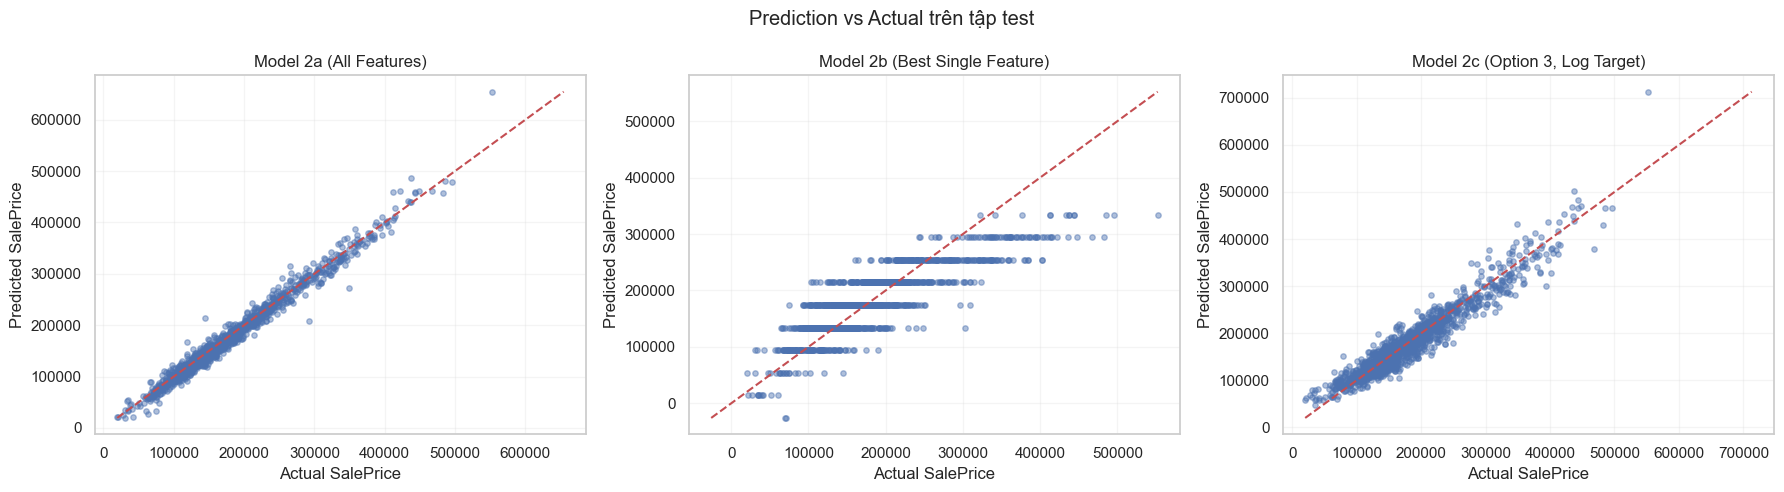

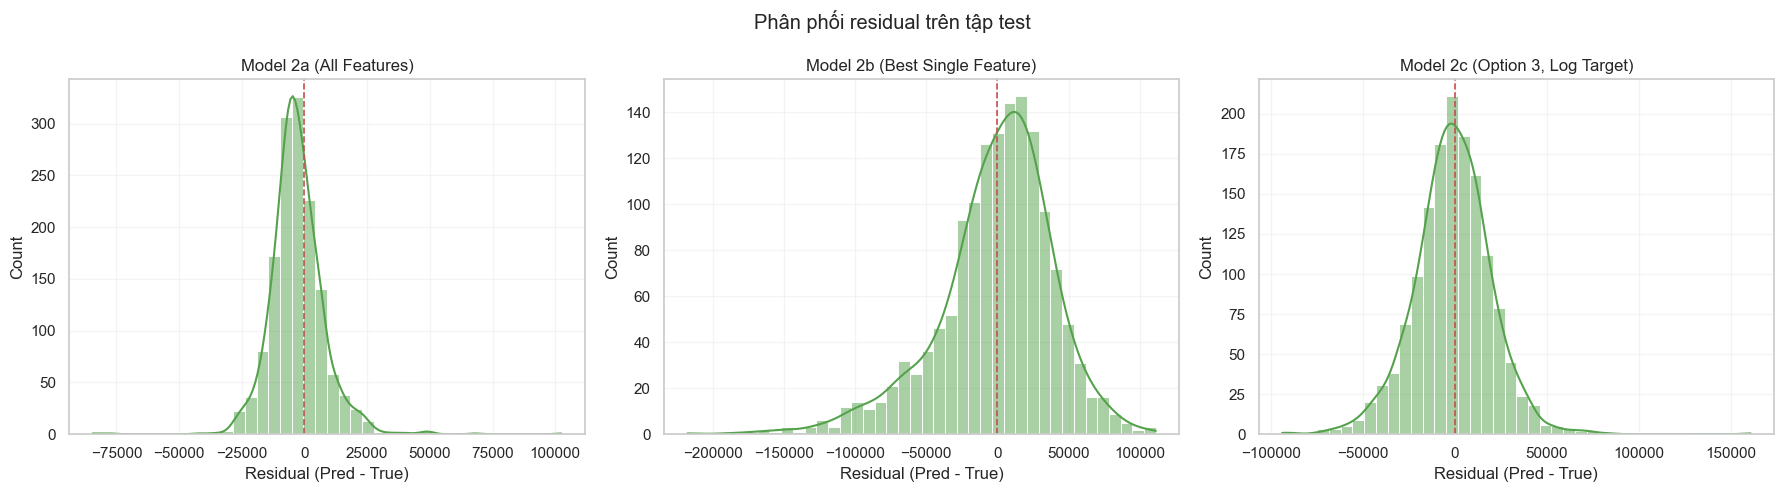

Model 2a (All Features): Train MAE=14,344.00 | Test MAE=8,235.59 | Gap=-6,108.41 USD
Model 2b (Best Single Feature): Train MAE=33,224.14 | Test MAE=30,535.70 | Gap=-2,688.44 USD
Model 2c (Option 3, Log Target): Train MAE=19,262.39 | Test MAE=15,905.82 | Gap=-3,356.57 USD


In [54]:
# Tổng hợp chẩn đoán cho 2a, 2b, 2c sau huấn luyện
models_diag = []

# 2a
pred_2a_train = model_2a.predict(X_train_2a_scaled) * TARGET_SCALE_2a
pred_2a_test = model_2a.predict(X_test_2a_scaled) * TARGET_SCALE_2a
models_diag.append({
    'name': 'Model 2a (All Features)',
    'y_train_true': y_train_full.to_numpy(),
    'y_test_true': y_test.to_numpy(),
    'y_train_pred': pred_2a_train,
    'y_test_pred': pred_2a_test
})

# 2b
pred_2b_train = model_2b.predict(X_train_2b) * TARGET_SCALE_2b
pred_2b_test = model_2b.predict(X_test_2b) * TARGET_SCALE_2b
models_diag.append({
    'name': 'Model 2b (Best Single Feature)',
    'y_train_true': y_train_np,
    'y_test_true': y_test_np,
    'y_train_pred': pred_2b_train,
    'y_test_pred': pred_2b_test
})

# 2c (Option 3, log-target)
pred_2c_train_log = my_best_model.predict(X_train_best_scaled)
pred_2c_test_log = my_best_model.predict(X_test_best_scaled)
pred_2c_train = np.expm1(np.clip(pred_2c_train_log, a_min=None, a_max=20))
pred_2c_test = np.expm1(np.clip(pred_2c_test_log, a_min=None, a_max=20))
models_diag.append({
    'name': 'Model 2c (Option 3, Log Target)',
    'y_train_true': y_train_best,
    'y_test_true': y_test_best,
    'y_train_pred': pred_2c_train,
    'y_test_pred': pred_2c_test
})

# 1) Bar chart MAE train/test
names = [m['name'] for m in models_diag]
mae_train_vals = [mean_absolute_error(m['y_train_true'], m['y_train_pred']) for m in models_diag]
mae_test_vals = [mean_absolute_error(m['y_test_true'], m['y_test_pred']) for m in models_diag]

x = np.arange(len(names))
w = 0.35
plt.figure(figsize=(12, 5))
plt.bar(x - w/2, mae_train_vals, width=w, label='Train MAE', color='#4C78A8')
plt.bar(x + w/2, mae_test_vals, width=w, label='Test MAE', color='#F58518')
plt.xticks(x, names, rotation=10)
plt.ylabel('MAE (USD)')
plt.title('So sánh MAE train/test giữa các mô hình')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Prediction vs Actual (test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, models_diag):
    y_true = m['y_test_true']
    y_pred = m['y_test_pred']
    ax.scatter(y_true, y_pred, s=15, alpha=0.45)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
    ax.set_title(m['name'])
    ax.set_xlabel('Actual SalePrice')
    ax.set_ylabel('Predicted SalePrice')
    ax.grid(alpha=0.2)
plt.suptitle('Prediction vs Actual trên tập test')
plt.tight_layout()
plt.show()

# 3) Residual distribution (test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, models_diag):
    residual = m['y_test_pred'] - m['y_test_true']
    sns.histplot(residual, bins=40, kde=True, ax=ax, color='#54A24B')
    ax.axvline(0, color='r', linestyle='--', linewidth=1.2)
    ax.set_title(m['name'])
    ax.set_xlabel('Residual (Pred - True)')
    ax.grid(alpha=0.2)
plt.suptitle('Phân phối residual trên tập test')
plt.tight_layout()
plt.show()

for name, tr, te in zip(names, mae_train_vals, mae_test_vals):
    gap = te - tr
    print(f"{name}: Train MAE={tr:,.2f} | Test MAE={te:,.2f} | Gap={gap:,.2f} USD")

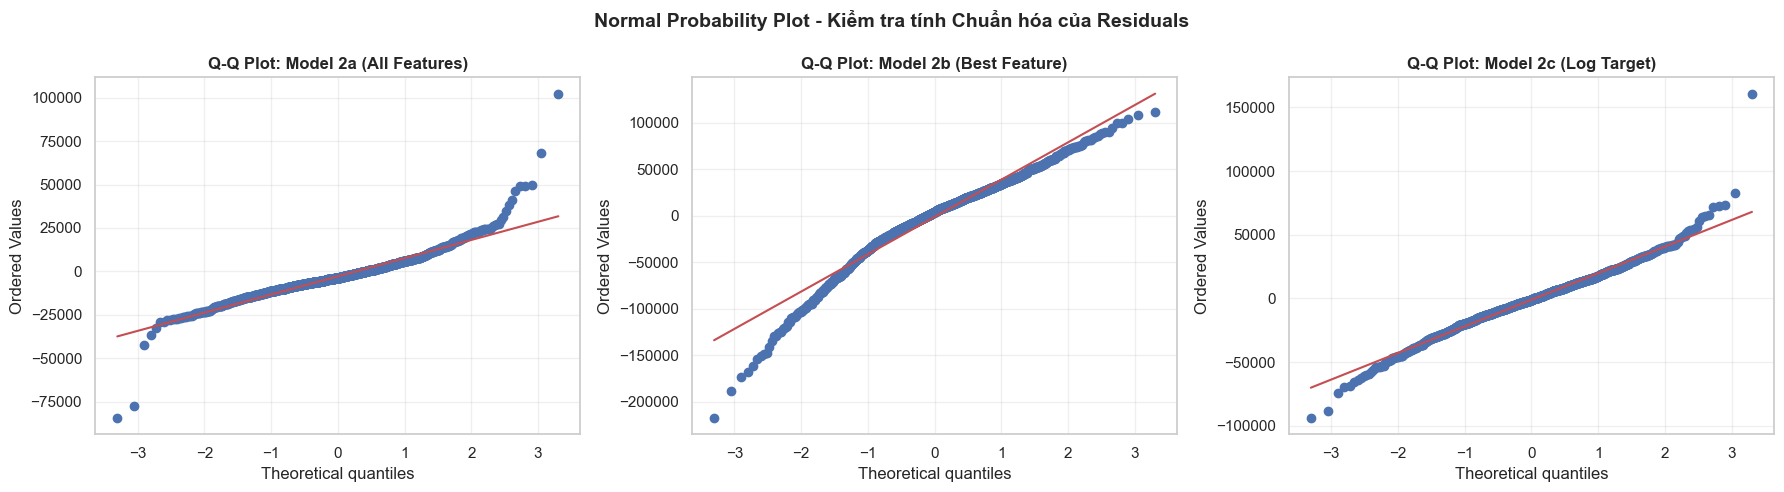

In [56]:
from scipy import stats
from scipy.stats import shapiro, normaltest

# Residual Analysis for all 3 models
residuals_2a = models_diag[0]['y_test_pred'] - models_diag[0]['y_test_true']
residuals_2b = models_diag[1]['y_test_pred'] - models_diag[1]['y_test_true']
residuals_2c = models_diag[2]['y_test_pred'] - models_diag[2]['y_test_true']

# Q-Q Plot analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, residuals, name_parts in zip(axes, 
                                     [residuals_2a, residuals_2b, residuals_2c],
                                     [('2a', 'All Features'),
                                      ('2b', 'Best Feature'),
                                      ('2c', 'Log Target')]):
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: Model {name_parts[0]} ({name_parts[1]})', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Normal Probability Plot - Kiểm tra tính Chuẩn hóa của Residuals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<>:82: SyntaxWarning: invalid escape sequence '\S'
<>:82: SyntaxWarning: invalid escape sequence '\S'
C:\Users\tranh\AppData\Local\Temp\ipykernel_22208\3932666045.py:82: SyntaxWarning: invalid escape sequence '\S'
  print(f"\Symbols: △ (Red) = Over-prediction | ▽ (Orange) = Under-prediction")


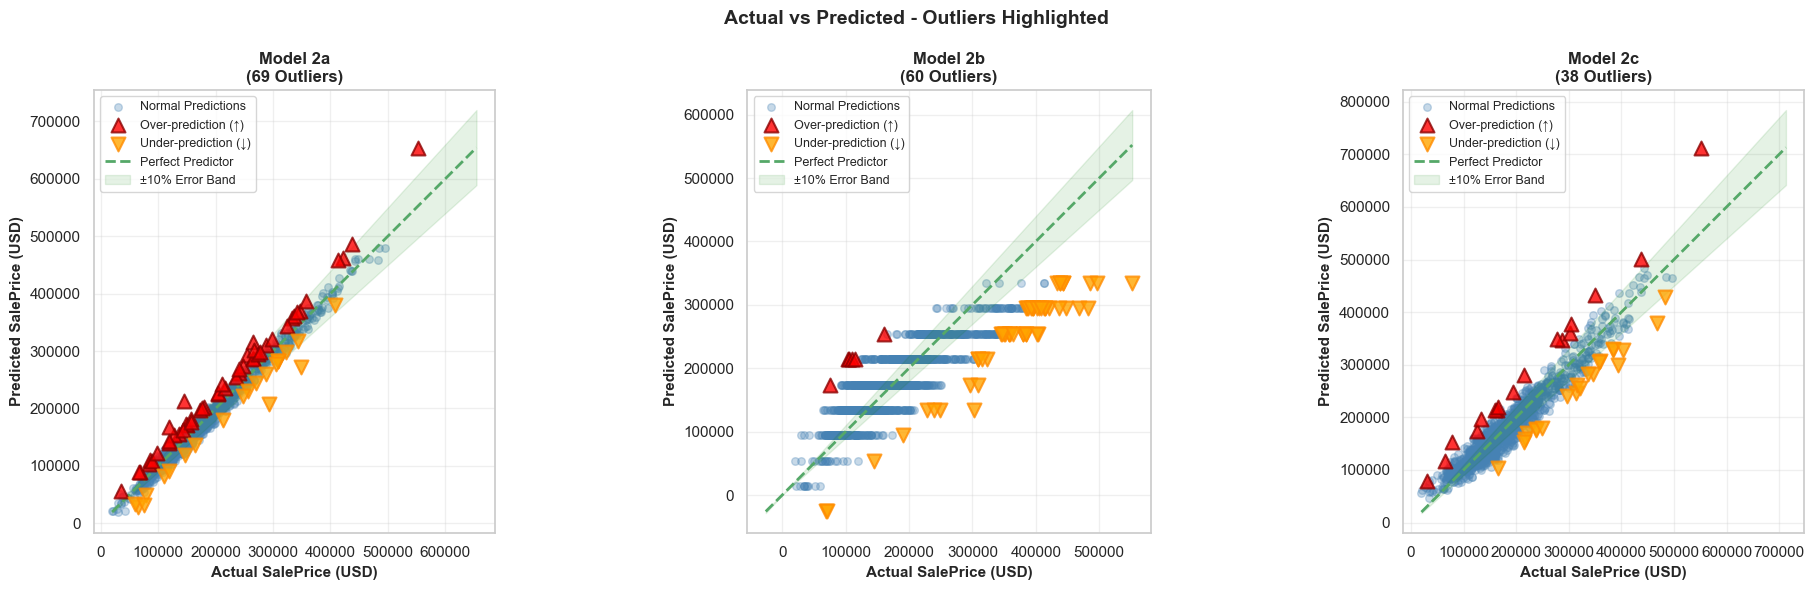


OUTLIER INDICES & SUMMARY:
Model 2a: 69 outliers detected
Model 2b: 60 outliers detected
Model 2c: 38 outliers detected
\Symbols: △ (Red) = Over-prediction | ▽ (Orange) = Under-prediction


In [59]:
# Define outlier detection function
def detect_outliers_iqr(data, multiplier=1.5):
    """Detect outliers using Interquartile Range (IQR) method"""
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

# Calculate outliers and their indices for all 3 models
outliers_2a, lb_2a, ub_2a = detect_outliers_iqr(residuals_2a)
outliers_2b, lb_2b, ub_2b = detect_outliers_iqr(residuals_2b)
outliers_2c, lb_2c, ub_2c = detect_outliers_iqr(residuals_2c)

outlier_indices_2a = np.where(outliers_2a)[0]
outlier_indices_2b = np.where(outliers_2b)[0]
outlier_indices_2c = np.where(outliers_2c)[0]

# Create scatter plots with outliers highlighted for each model
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_info = [
    (models_diag[0], outlier_indices_2a, outliers_2a, 'Model 2a'),
    (models_diag[1], outlier_indices_2b, outliers_2b, 'Model 2b'),
    (models_diag[2], outlier_indices_2c, outliers_2c, 'Model 2c')
]

for ax, (m, outlier_indices, outliers_mask, model_name) in zip(axes, models_info):
    y_true = m['y_test_true']
    y_pred = m['y_test_pred']
    
    # Plot normal predictions
    normal_mask = ~outliers_mask
    ax.scatter(y_true[normal_mask], y_pred[normal_mask], 
              s=30, alpha=0.3, c='steelblue', label='Normal Predictions', zorder=1)
    
    # Plot outliers: over-prediction vs under-prediction
    if np.sum(outliers_mask) > 0:
        errors = y_pred[outliers_mask] - y_true[outliers_mask]
        over_pred = errors > 0
        under_pred = errors <= 0
        
        if np.sum(over_pred) > 0:
            ax.scatter(y_true[outliers_mask][over_pred], y_pred[outliers_mask][over_pred],
                      s=100, alpha=0.8, c='red', marker='^', label='Over-prediction (↑)', 
                      edgecolors='darkred', linewidth=1.5, zorder=5)
        
        if np.sum(under_pred) > 0:
            ax.scatter(y_true[outliers_mask][under_pred], y_pred[outliers_mask][under_pred],
                      s=100, alpha=0.8, c='orange', marker='v', label='Under-prediction (↓)',
                      edgecolors='darkorange', linewidth=1.5, zorder=5)
    
    # Perfect prediction line
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'g--', linewidth=2, label='Perfect Predictor', zorder=3)
    
    # ±10% error bands
    ax.fill_between([lo, hi], [lo*0.9, hi*0.9], [lo*1.1, hi*1.1], 
                     alpha=0.1, color='green', label='±10% Error Band', zorder=2)
    
    ax.set_xlabel('Actual SalePrice (USD)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Predicted SalePrice (USD)', fontweight='bold', fontsize=11)
    ax.set_title(f'{model_name}\n({len(outlier_indices)} Outliers)', 
                fontweight='bold', fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Actual vs Predicted - Outliers Highlighted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("OUTLIER INDICES & SUMMARY:")
print("="*100)
print(f"Model 2a: {len(outlier_indices_2a)} outliers detected")
print(f"Model 2b: {len(outlier_indices_2b)} outliers detected")
print(f"Model 2c: {len(outlier_indices_2c)} outliers detected")
print(f"\Symbols: △ (Red) = Over-prediction | ▽ (Orange) = Under-prediction")